In [1]:
#Exercise 46
"""We are given the data of [KNBNH16], where the authors study the
maltose-binding protein (MBP). Such a protein can be grouped into 370 components,
called amino acid residues. There is two types of MBPs: open and closed. The goal is
to identify these types from topological properties of the proteins.
69
The daset consists in 14 correlation matrices, each matrix representing correlations
between the 370 components of a protein. Transform the matrices of correlations into
matrices of distances, via the formula Di,j = 1−|Ci,j |. Then, compute the 1-Betti curves
of the Rips complex for each of these matrices of distances. Compare the Betti curves
of the different proteins. Do you recognize two different types of proteins (open and
closed)?
"""

def OpenDatasetEx46(i, structure):
    if structure == 'closed': file = 'Exercise46/closed'+repr(i)+'.txt'
    if structure == 'open': file = 'Exercise46/open'+repr(i)+'.txt' 
    corr = open(file).read()
    corr = np.asarray([[float(a) for a in item.split()] for item in corr.split('\n')[:-1]])
    return corr

def corr_to_dist(corr):
    return 1 - np.abs(corr)


i = 1 
Betti numbers closed:
The Betti numbers are:
Beta_0 = 5
Beta_1 = 10

Betti numbers open:
The Betti numbers are:
Beta_0 = 1
Beta_1 = 6
--------------------------------------------------
i = 2 
Betti numbers closed:
The Betti numbers are:
Beta_0 = 3
Beta_1 = 7

Betti numbers open:
The Betti numbers are:
Beta_0 = 3
Beta_1 = 2
--------------------------------------------------
i = 3 
Betti numbers closed:
The Betti numbers are:
Beta_0 = 4
Beta_1 = 7

Betti numbers open:
The Betti numbers are:
Beta_0 = 3
Beta_1 = 2
--------------------------------------------------
i = 4 
Betti numbers closed:
The Betti numbers are:
Beta_0 = 4
Beta_1 = 5

Betti numbers open:
The Betti numbers are:
Beta_0 = 1
Beta_1 = 1
--------------------------------------------------
i = 5 
Betti numbers closed:
The Betti numbers are:
Beta_0 = 3
Beta_1 = 8

Betti numbers open:
The Betti numbers are:
Beta_0 = 2
Beta_1 = 1
--------------------------------------------------
i = 6 
Betti numbers closed:
The Betti numbe

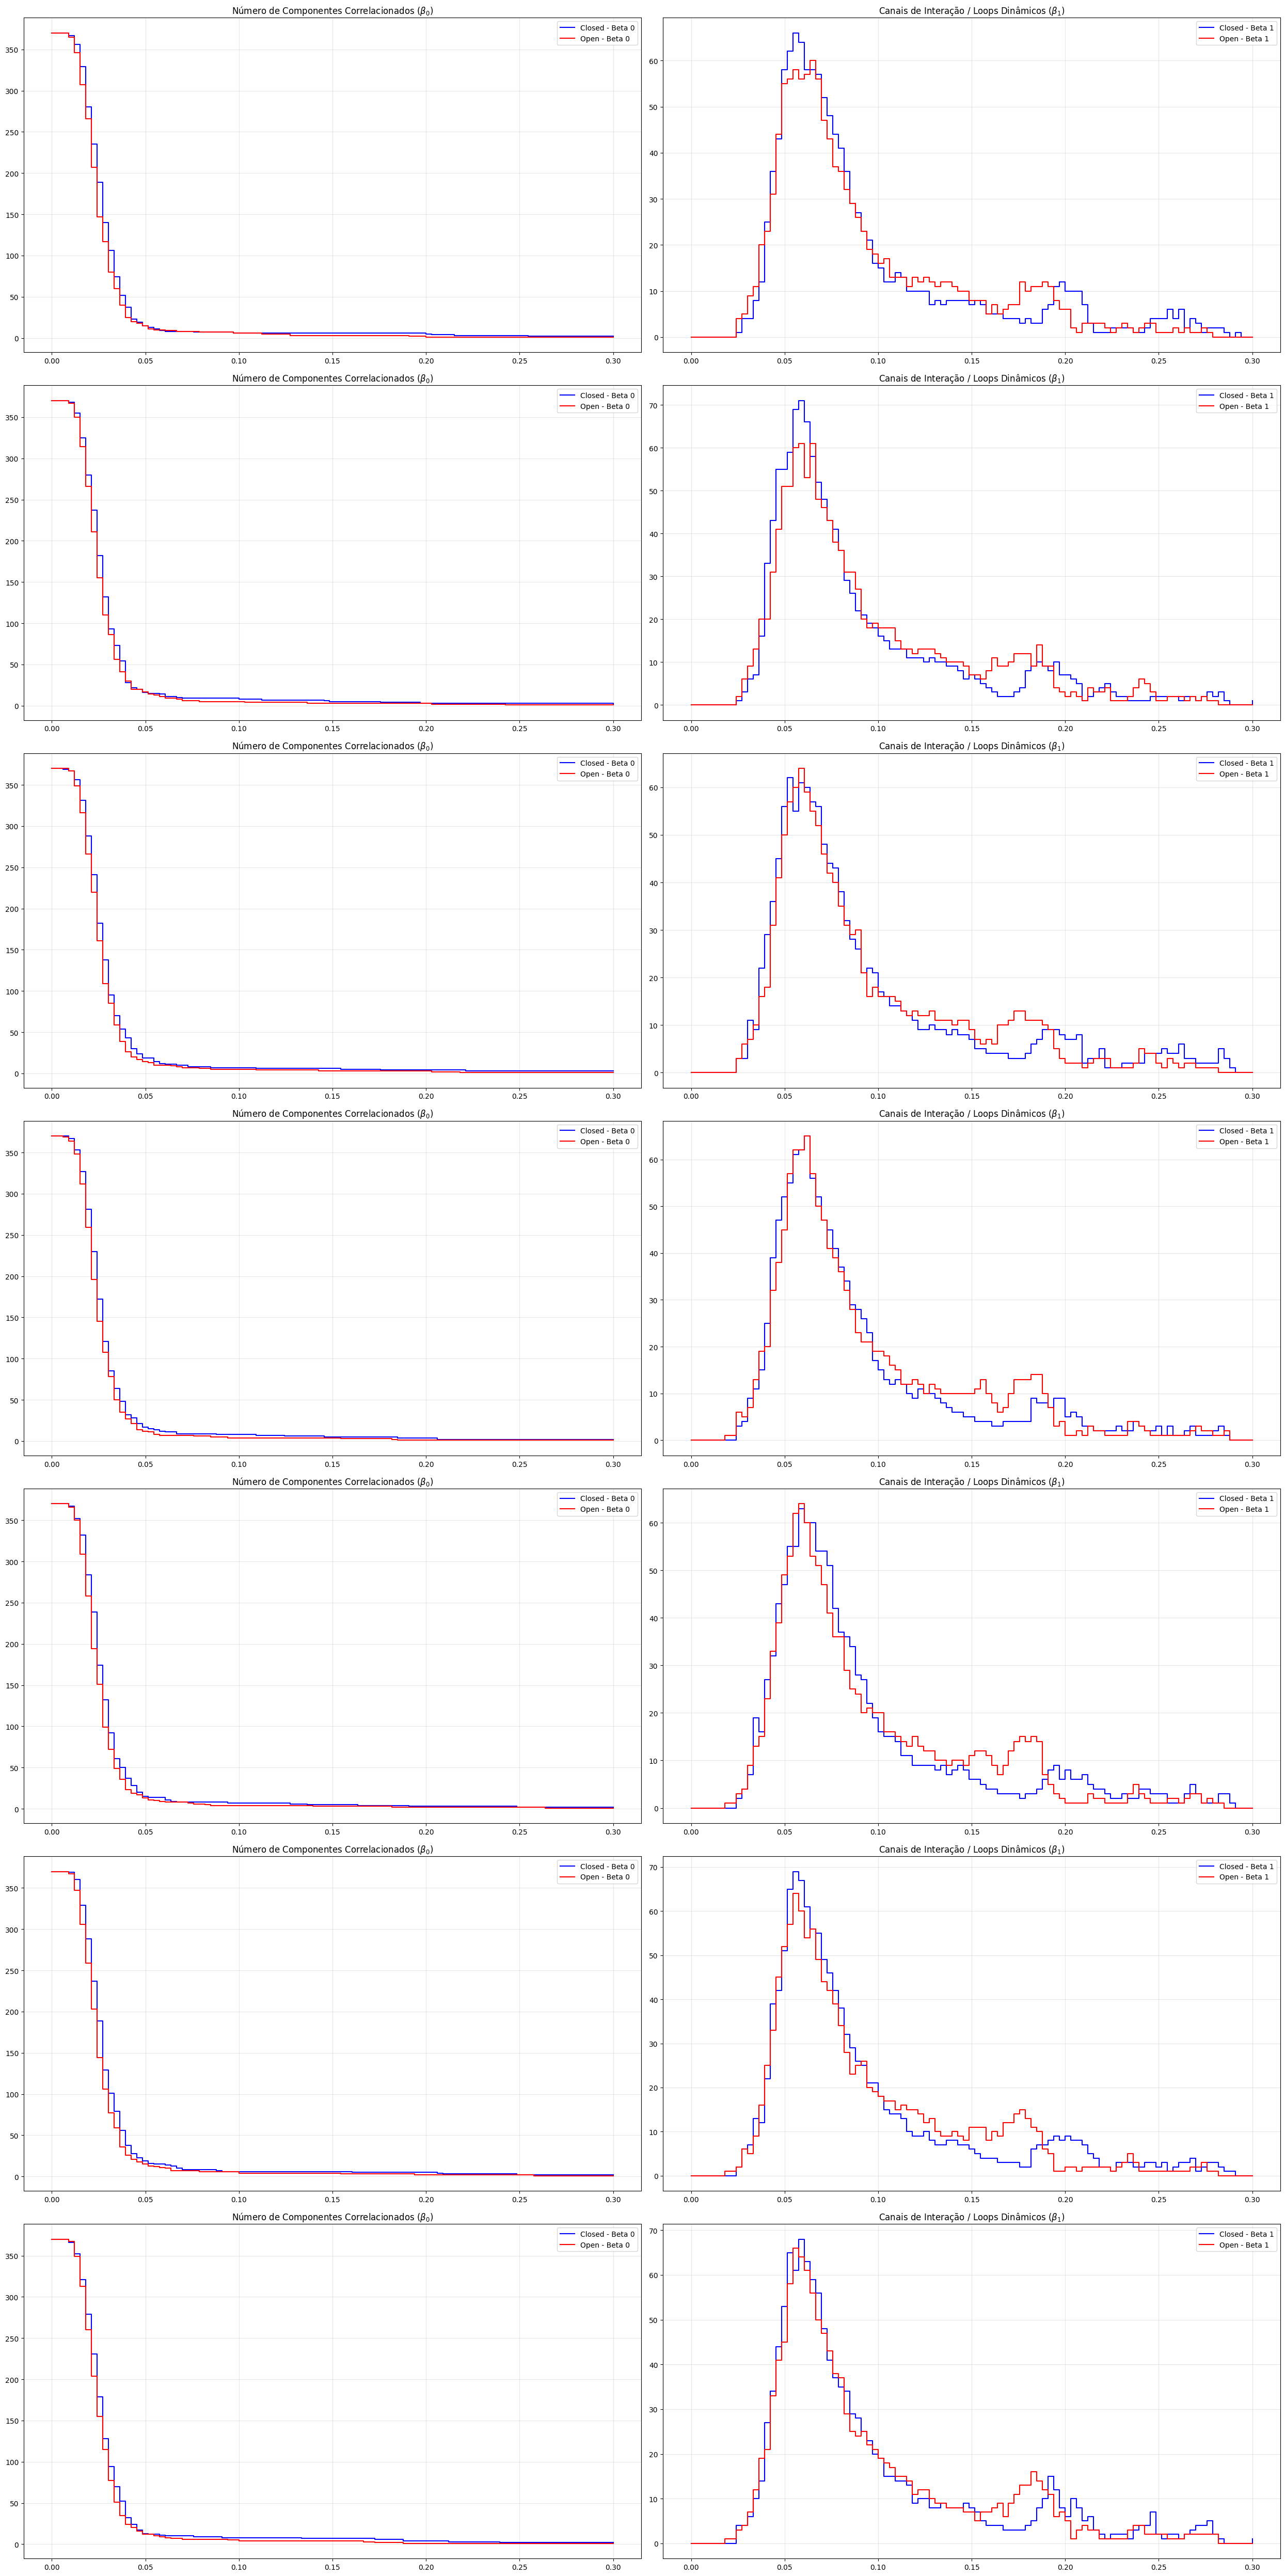

In [3]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(25, 50))
J = np.linspace(0, 0.3, 100)

t = 0.2
l_open, l_closed = [], []

for i in range(1, 8):
    
    corr_closed = OpenDatasetEx46(i, 'closed')
    corr_open = OpenDatasetEx46(i, 'open')

    dist_closed = corr_to_dist(corr_closed)
    dist_open = corr_to_dist(corr_open)
    

    curvas_closed = GetBettiCurvesFromDistances(dist_closed, J, dim=2)
    curvas_open = GetBettiCurvesFromDistances(dist_open, J, dim=2)

    rips_closed = gudhi.RipsComplex(distance_matrix = dist_closed, max_edge_length = 2*t)
    st_closed = rips_closed.create_simplex_tree(max_dimension=2)  
    l_closed.append(curvas_closed[1])

    rips_open = gudhi.RipsComplex(distance_matrix = dist_open, max_edge_length = 2*t)
    st_open = rips_open.create_simplex_tree(max_dimension=2)  
    l_open.append(curvas_open[1])

    print(f"i = {i} \nBetti numbers closed:")
    BettiNumbers(st_closed)
    print()
    print("Betti numbers open:")
    BettiNumbers(st_open)
    print(50*"-")

    ax0 = axes[i-1, 0]
    ax0.plot(J, curvas_closed[0], label='Closed - Beta 0', color='blue', drawstyle="steps-post")
    ax0.plot(J, curvas_open[0], label='Open - Beta 0', color='red', drawstyle="steps-post")
    ax0.set_title('Número de Componentes Correlacionados ($\\beta_0$)')
    ax0.legend(loc='upper right', fontsize='small')
    ax0.grid(alpha=0.3)
    ax0.legend()

    ax1 = axes[i-1, 1]
    ax1.plot(J, curvas_closed[1], label='Closed - Beta 1', color='blue', drawstyle="steps-post")
    ax1.plot(J, curvas_open[1], label='Open - Beta 1', color='red', drawstyle="steps-post")
    ax1.set_title('Canais de Interação / Loops Dinâmicos ($\\beta_1$)')
    ax1.legend(loc='upper right', fontsize='small')
    ax1.grid(alpha=0.3)
    ax1.legend()


mediac = np.mean(l_closed)
mediao = np.mean(l_open)

desvioc = np.std(l_closed)
desvioo = np.std(l_open)

print(f"Média e Desvio Padrão (Closed): {mediac:.2f} | {desvioc:.2f}\nMédia e Desvio Padrão (Open)  : {mediao:.2f} | {desvioo:.2f}")
plt.tight_layout()

plt.show()

Gerando Diagramas de Persistência...


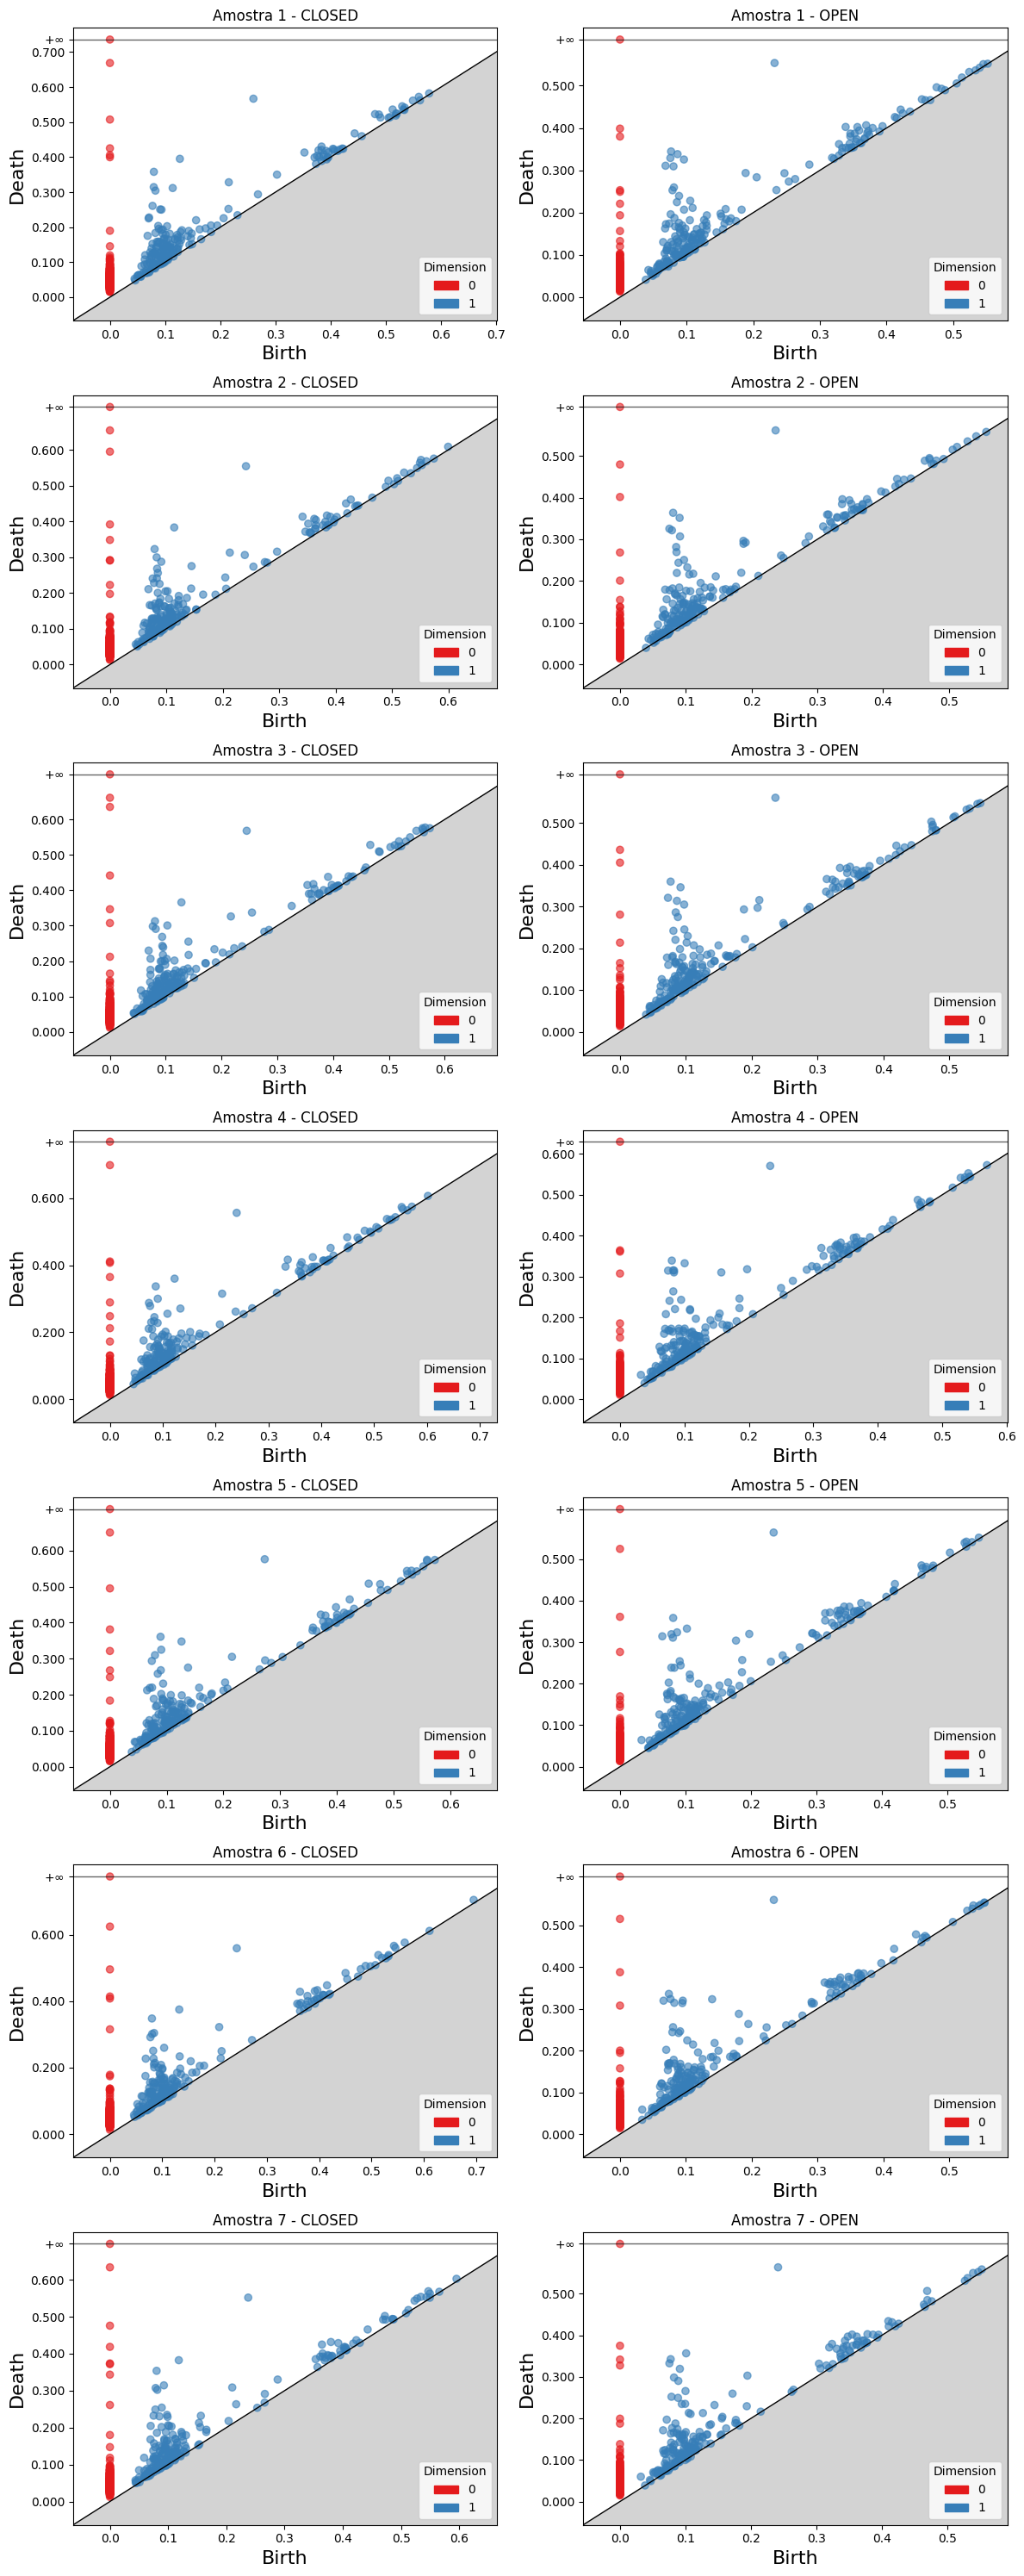

In [ ]:
def plot_diagram(st, ax, title):
    persistence = st.persistence(homology_coeff_field=2)
    gudhi.plot_persistence_diagram(persistence, axes=ax)
    ax.set_title(title)

fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(12, 30))

max_dist_analysis = 0.8 

for i in range(1, 8):
    row_idx = i - 1
    
    corr_closed = OpenDatasetEx46(i, 'closed')
    corr_open = OpenDatasetEx46(i, 'open')

    dist_closed = corr_to_dist(corr_closed)
    dist_open = corr_to_dist(corr_open)

    rips_closed = gudhi.RipsComplex(distance_matrix=dist_closed, max_edge_length=max_dist_analysis)
    st_closed = rips_closed.create_simplex_tree(max_dimension=2)
    
    rips_open = gudhi.RipsComplex(distance_matrix=dist_open, max_edge_length=max_dist_analysis)
    st_open = rips_open.create_simplex_tree(max_dimension=2)

    plot_diagram(st_closed, axes[row_idx, 0], f'Amostra {i} - CLOSED')

    plot_diagram(st_open, axes[row_idx, 1], f'Amostra {i} - OPEN')

plt.tight_layout()
plt.show()

**MATRIZ CORRELAÇÃO EXEMPLO DO ARTIGO**

In [4]:
import numpy as np
from prody import parseMMCIF, ANM, calcCrossCorr

In [6]:
corrmatrix = np.load("matrizes/holo/4MBP_matriz.npy")

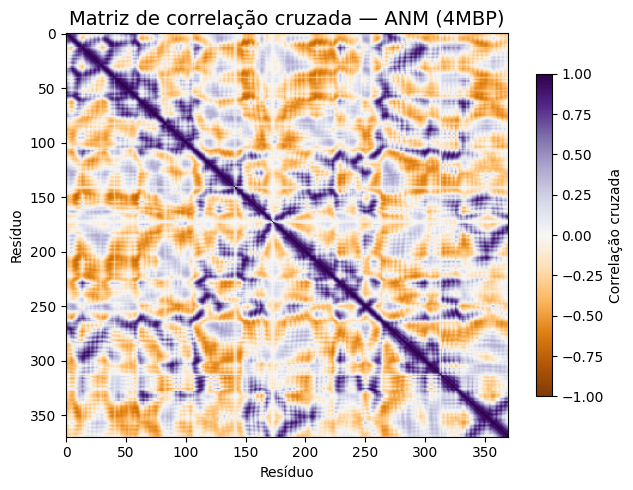

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corrmatrix, cmap='PuOr', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlação cruzada', shrink=0.8)
ax.set_title('Matriz de correlação cruzada — ANM (4MBP)', fontsize=14)
ax.set_xlabel('Resíduo')
ax.set_ylabel('Resíduo')
plt.tight_layout()
plt.show()

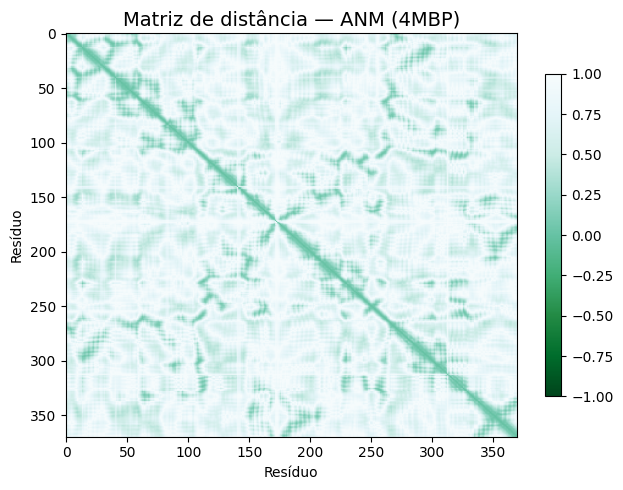

In [8]:
dmatrix = 1 - abs(corrmatrix)

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(dmatrix, cmap='BuGn_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de distância — ANM (4MBP)', fontsize=14)
ax.set_xlabel('Resíduo')
ax.set_ylabel('Resíduo')
plt.tight_layout()
plt.show()

**Baixando proteinas com a estrutura MBP**

In [1]:
from rcsbapi.search import AttributeQuery, NestedAttributeQuery

print("Buscando estruturas MBP (UniProt P0AEX9)...")

# Busca usando a estrutura aninhada exigida pela versão mais nova da API
query = NestedAttributeQuery(
    # O nome do banco de dados de referência é o UniProt
    AttributeQuery(
        attribute="rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_name", 
        operator="exact_match", 
        value="UniProt"
    ),
    # O código dentro do UniProt é o da nossa MBP
    AttributeQuery(
        attribute="rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession", 
        operator="exact_match", 
        value="P0AEX9"
    )
)
pdb_ids = list(query())
print("Estruturas encontradas:")
print(len(pdb_ids))

Buscando estruturas MBP (UniProt P0AEX9)...
Estruturas encontradas:
527


In [15]:
from rcsbapi.data import DataQuery
import json

print("\n" + "=" * 70)
print("PASSO 3: OBTENDO INFORMAÇÕES DE LIGANTES (CORRIGIDO)")
print("=" * 70)

print(f"\nProcessando {len(pdb_ids)} estruturas...")

# Usar DataQuery com CAMPOS CORRETOS
try:
    query = DataQuery(
        input_type="entries",
        input_ids=pdb_ids,
        return_data_list=[
            # 1. Conta açúcares/oligossacarídeos (Maltose, Ciclodextrina, etc)
            "rcsb_entry_info.branched_entity_count", 
            
            # 2. Conta pequenos íons ou moléculas simples (Cálcio, Zinco, Sulfato)
            "rcsb_entry_info.nonpolymer_entity_count", 
            
            # 3. Lista o nome exato (sigla) das moléculas pequenas, se houver
            "nonpolymer_entities.rcsb_nonpolymer_entity_container_identifiers.nonpolymer_comp_id",
            
            # 4. Resolução universal (funciona para Raio-X e Cryo-EM)
            "rcsb_entry_info.resolution_combined",
            
            "citation.title",
            "exptl.method"
        ]
    )
    
    resultado = query.exec()
    print(f"\n✓ Dados obtidos com sucesso!")
    
    # Salvar resultado em JSON
    with open("ligantes_raw.json", "w") as f:
        json.dump(resultado, f, indent=2)
        
    print(f"✓ Salvo em: ligantes_raw.json")

except Exception as e:
    print(f"\n✗ Erro: {e}")


PASSO 3: OBTENDO INFORMAÇÕES DE LIGANTES (CORRIGIDO)

Processando 527 estruturas...

✓ Dados obtidos com sucesso!
✓ Salvo em: ligantes_raw.json


In [3]:
import json

print("\n" + "=" * 70)
print("PASSO 4: SEPARANDO APO E HOLO")
print("=" * 70)

# Carrega o JSON perfeito que você acabou de gerar
with open("ligantes_raw.json", "r") as f:
    resultado = json.load(f)

proteinas_holo = []
proteinas_apo = []

# Percorre todas as estruturas do arquivo
for entry in resultado["data"]["entries"]:
    pdb_id = entry["rcsb_id"]
    
    # Pega as informações da proteína
    entry_info = entry.get("rcsb_entry_info", {})
    
    # Se o campo não existir, assumimos 0 (segurança extra)
    branched_count = entry_info.get("branched_entity_count")
    if branched_count is None:
        branched_count = 0
        
    # Lógica de separação: Tem açúcar? É Holo. Não tem? É Apo.
    if branched_count > 0:
        proteinas_holo.append(pdb_id)
    else:
        proteinas_apo.append(pdb_id)

print(f"✓ Total processado: {len(proteinas_holo) + len(proteinas_apo)}")
print(f"➜ Proteínas HOLO (Fechadas): {len(proteinas_holo)}")
print(f"➜ Proteínas APO (Abertas): {len(proteinas_apo)}")


PASSO 4: SEPARANDO APO E HOLO
✓ Total processado: 527
➜ Proteínas HOLO (Fechadas): 281
➜ Proteínas APO (Abertas): 246


In [20]:
import os
import numpy as np
import prody as pr

print("\n" + "=" * 70)
print("PASSO 5 e 6: PIPELINE COMPLETO (DOWNLOAD + ANM + MATRIZES)")
print("=" * 70)

# Configura o ProDy para não poluir muito a tela com mensagens
pr.confProDy(verbosity='info')

def processar_pipeline(lista_ids, categoria):
    # 1. Cria as pastas para os arquivos CIF e para as MATRIZES
    pasta_cif = f"dataset/{categoria}"
    pasta_matriz = f"matrizes/{categoria}"
    
    os.makedirs(pasta_cif, exist_ok=True)
    os.makedirs(pasta_matriz, exist_ok=True)
    
    total = len(lista_ids)
    sucessos = 0
    
    for i, pdb_id in enumerate(lista_ids):
        print(f"\n[{i+1}/{total}] Processando {pdb_id} ({categoria.upper()})...")
        try:
            # 2. O truque do ProDy: Baixa o .cif direto para a pasta correta (se não existir)
            # O fetchPDB retorna o caminho completo do arquivo baixado no seu computador
            caminho_arquivo = pr.fetchPDB(pdb_id, folder=pasta_cif, format='cif')
            
            # 3. Lê o arquivo baixado
            protein = pr.parseMMCIF(caminho_arquivo)
            
            # 4. Seleciona os carbonos alfa
            calphas = protein.select("calpha and chain A")
            
            if calphas is None:
                print(f"  ✗ Erro: Não encontrou carbonos alfa para {pdb_id}.")
                continue
                
            # 5. Matemática do Modelo ANM
            anm = pr.ANM(f'ANM_{pdb_id}')
            anm.buildHessian(calphas)
            anm.calcModes()
            
            # 6. Calcula a matriz de correlação cruzada
            corrmatrix = pr.calcCrossCorr(anm)
            
            # 7. Salva a matriz em formato binário do NumPy (.npy)
            caminho_salvar = os.path.join(pasta_matriz, f"{pdb_id}_matriz.npy")
            np.save(caminho_salvar, corrmatrix)
            
            # Pega o tamanho real da matriz para você acompanhar
            tamanho = corrmatrix.shape[0]
            print(f"  ✓ Concluído! Matriz {tamanho}x{tamanho} salva.")
            sucessos += 1
            
        except Exception as e:
            print(f"  ✗ Falha ao processar {pdb_id}: {e}")
            
    print(f"\nResumo {categoria.upper()}: {sucessos} de {total} matrizes geradas com sucesso.")

# Executando o Pipeline para as listas que você já tinha isolado no Passo 4!
# (Assumindo que as variáveis proteinas_holo e proteinas_apo estejam carregadas)
print("\n➜ INICIANDO LOTE HOLO...")
processar_pipeline(proteinas_holo, "holo")

print("\n➜ INICIANDO LOTE APO...")
processar_pipeline(proteinas_apo, "apo")

@> ProDy is configured: verbosity='info'



PASSO 5 e 6: PIPELINE COMPLETO (DOWNLOAD + ANM + MATRIZES)

➜ INICIANDO LOTE HOLO...

[1/281] Processando 1ANF (HOLO)...


@> Downloading PDB files via FTP failed, trying HTTP.
@> Downloading PDB files via FTP failed, trying HTTP.


  ✓ Concluído! Matriz 370x370 salva.

[2/281] Processando 1FQB (HOLO)...


@> Downloading PDB files via FTP failed, trying HTTP.


...

  ✓ Concluído! Matriz 534x534 salva.

[244/246] Processando 9WBG (APO)...


@> Downloading PDB files via FTP failed, trying HTTP.


  ✓ Concluído! Matriz 196x196 salva.

[245/246] Processando 9WY8 (APO)...


@> Downloading PDB files via FTP failed, trying HTTP.


  ✓ Concluído! Matriz 495x495 salva.

[246/246] Processando 9XQC (APO)...
  ✓ Concluído! Matriz 233x233 salva.

Resumo APO: 233 de 246 matrizes geradas com sucesso.


In [ ]:
import os

print("\n" + "=" * 70)
print("PASSO 7: AUDITORIA DE ARQUIVOS FALTANTES")
print("=" * 70)

def auditar_pasta(lista_esperada, pasta_arquivos, extensao):
    # 1. Se a pasta não existir ainda, retorna que todos estão faltando
    if not os.path.exists(pasta_arquivos):
        return lista_esperada
        
    # 2. Lista todos os arquivos da pasta
    arquivos_na_pasta = os.listdir(pasta_arquivos)
    
    # 3. Pega apenas o ID do arquivo (ex: corta o ".cif" ou "_matriz.npy" do nome)
    ids_encontrados = []
    for arquivo in arquivos_na_pasta:
        if arquivo.endswith(extensao):
            # Pega só os 4 primeiros caracteres (o PDB ID)
            pdb_id = arquivo[:4].upper() 
            ids_encontrados.append(pdb_id)
            
    # 4. A Mágica dos Conjuntos: Esperado MINUS Encontrado
    set_esperado = set(lista_esperada)
    set_encontrado = set(ids_encontrados)
    
    ids_faltantes = list(set_esperado - set_encontrado)
    
    return ids_faltantes

# --- AUDITORIA DOS ARQUIVOS .CIF (DOWNLOAD) ---
print("\n➜ Verificando Downloads (.cif.gz):")
cif_faltantes_holo = auditar_pasta(proteinas_holo, "dataset/holo", ".cif.gz")
cif_faltantes_apo = auditar_pasta(proteinas_apo, "dataset/apo", ".cif.gz")

print(f"HOLO Faltantes ({len(cif_faltantes_holo)}): {cif_faltantes_holo}")
print(f"APO Faltantes ({len(cif_faltantes_apo)}): {cif_faltantes_apo}")

# --- AUDITORIA DAS MATRIZES (.NPY) ---
print("\n➜ Verificando Matrizes Geradas (.npy):")
matriz_faltantes_holo = auditar_pasta(proteinas_holo, "matrizes/holo", ".npy")
matriz_faltantes_apo = auditar_pasta(proteinas_apo, "matrizes/apo", ".npy")

print(f"Matrizes HOLO Faltantes ({len(matriz_faltantes_holo)}): {matriz_faltantes_holo}")
print(f"Matrizes APO Faltantes ({len(matriz_faltantes_apo)}): {matriz_faltantes_apo}")


PASSO 7: AUDITORIA DE ARQUIVOS FALTANTES

➜ Verificando Downloads (.cif):
HOLO Faltantes (0): []
APO Faltantes (0): []

➜ Verificando Matrizes Geradas (.npy):
Matrizes HOLO Faltantes (2): ['6DKS', '1T0K']
Matrizes APO Faltantes (13): ['8GKH', '9CF3', '9CET', '9CEZ', '9CEV', '2V93', '9PGN', '9CEU', '9CEW', '9CEY', '9CES', '8VG0', '9CEX']


In [17]:
import os
import numpy as np
import prody as pr

print("\n" + "=" * 70)
print("PASSO 8: RESGATE DAS MATRIZES FALTANTES")
print("=" * 70)

pr.confProDy(verbosity='none') # Oculta os avisos padrões para vermos só nossos prints

def resgatar_matrizes(lista_faltantes, categoria):
    if not lista_faltantes:
        print(f"➜ Nenhuma matriz faltando na categoria {categoria.upper()}! Tudo certo.")
        return

    pasta_cif = f"dataset/{categoria}"
    pasta_matriz = f"matrizes/{categoria}"
    sucessos = 0
    
    print(f"\nIniciando resgate de {len(lista_faltantes)} proteínas ({categoria.upper()})...")

    for pdb_id in lista_faltantes:
        try:
            # 1. Localiza o arquivo que já foi baixado (tenta .cif e .cif.gz)
            caminho_arquivo = os.path.join(pasta_cif, f"{pdb_id}.cif")
            if not os.path.exists(caminho_arquivo):
                caminho_arquivo += ".gz" 
                
            # Se por algum motivo não achar, manda o ProDy baixar rapidinho
            if not os.path.exists(caminho_arquivo):
                caminho_arquivo = pr.fetchPDB(pdb_id, folder=pasta_cif, format='cif')

            # 2. Abre a molécula
            protein = pr.parseMMCIF(caminho_arquivo)
            if protein is None:
                continue

            # 3. ESTRATÉGIA DE RESGATE: Descobre quais cadeias existem
            todos_calphas = protein.select('calpha')
            if todos_calphas is None:
                print(f"  ✗ Erro: Não há carbonos alfa na estrutura {pdb_id}.")
                continue
                
            # Pega as letras únicas de todas as cadeias e ordena (ex: ['B', 'C'])
            cadeias_disponiveis = list(set(todos_calphas.getChids()))
            cadeias_disponiveis.sort()
            
            # Pega a primeira cadeia existente
            cadeia_alvo = cadeias_disponiveis[0]
            
            # 4. Seleciona os resíduos apenas da cadeia encontrada
            calphas = protein.select(f"calpha and chain {cadeia_alvo}")
            tamanho = calphas.numAtoms()
            
            print(f"➜ {pdb_id}: Cadeia A ausente. Usando a cadeia '{cadeia_alvo}' (Tamanho: {tamanho} resíduos).")
            
            # Alerta de Segurança para o seu Machine Learning (esperamos aprox 370 resíduos)
            if tamanho < 340 or tamanho > 400:
                print(f"    ⚠️ AVISO: O tamanho dessa cadeia ({tamanho}) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!")

            # 5. Calcula ANM e gera a matriz de correlação
            anm = pr.ANM(f'ANM_{pdb_id}')
            anm.buildHessian(calphas)
            anm.calcModes()
            
            corrmatrix = pr.calcCrossCorr(anm)
            
            # 6. Salva a matriz
            caminho_salvar = os.path.join(pasta_matriz, f"{pdb_id}_matriz.npy")
            np.save(caminho_salvar, corrmatrix)
            
            print(f"    ✓ Matriz {pdb_id}_matriz.npy gerada com sucesso!")
            sucessos += 1

        except Exception as e:
            print(f"  ✗ Falha ao processar {pdb_id}: {e}")

    print(f"\nResultado final {categoria.upper()}: {sucessos}/{len(lista_faltantes)} recuperadas.")

# Chama a função passando as variáveis de IDs faltantes que você encontrou no passo anterior
# (Certifique-se de que matriz_faltantes_holo e matriz_faltantes_apo estejam na memória)
resgatar_matrizes(matriz_faltantes_holo, "holo")
resgatar_matrizes(matriz_faltantes_apo, "apo")

@> ProDy is configured: verbosity='none'



PASSO 8: RESGATE DAS MATRIZES FALTANTES

Iniciando resgate de 2 proteínas (HOLO)...
➜ 6DKS: Cadeia A ausente. Usando a cadeia 'C' (Tamanho: 417 resíduos).
    ⚠️ AVISO: O tamanho dessa cadeia (417) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!
    ✓ Matriz 6DKS_matriz.npy gerada com sucesso!
➜ 1T0K: Cadeia A ausente. Usando a cadeia 'C' (Tamanho: 365 resíduos).
    ✓ Matriz 1T0K_matriz.npy gerada com sucesso!

Resultado final HOLO: 2/2 recuperadas.

Iniciando resgate de 13 proteínas (APO)...
➜ 8GKH: Cadeia A ausente. Usando a cadeia 'B' (Tamanho: 600 resíduos).
    ⚠️ AVISO: O tamanho dessa cadeia (600) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!
    ✓ Matriz 8GKH_matriz.npy gerada com sucesso!
➜ 9CF3: Cadeia A ausente. Usando a cadeia 'B' (Tamanho: 162 resíduos).
    ⚠️ AVISO: O tamanho dessa cadeia (162) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!
    ✓ Matriz 9CF3_matriz.npy gerada com sucesso!
➜ 9CET: Cadeia 

In [20]:
import os
import numpy as np

print("\n" + "=" * 70)
print("PASSO 9: DIAGNÓSTICO DE SHAPES DAS MATRIZES")
print("=" * 70)

def auditar_dimensoes(categoria, tamanho_esperado=370):
    pasta_matrizes = f"matrizes/{categoria}"
    if not os.path.exists(pasta_matrizes):
        return []
        
    arquivos = [f for f in os.listdir(pasta_matrizes) if f.endswith('.npy')]
    anomalos = []
    
    for arquivo in arquivos:
        caminho_arquivo = os.path.join(pasta_matrizes, arquivo)
        # Carrega a matriz para ler o tamanho
        matriz = np.load(caminho_arquivo)
        tamanho = matriz.shape[0] # Pega o N da matriz NxN
        
        # Se for diferente do esperado, guarda na lista
        if tamanho != tamanho_esperado:
            pdb_id = arquivo[:4] # Pega as 4 primeiras letras (o ID)
            anomalos.append((pdb_id, tamanho))
            
    # Ordena a lista do menor para o maior tamanho para facilitar a leitura
    anomalos.sort(key=lambda x: x[1])
    
    print(f"\n➜ Categoria {categoria.upper()} ({len(arquivos)} matrizes analisadas):")
    if not anomalos:
         print(f"  ✓ Todas as matrizes têm exatos {tamanho_esperado}x{tamanho_esperado}!")
    else:
         print(f"  ⚠️ Encontradas {len(anomalos)} matrizes fora do padrão:")
         for pdb_id, tam in anomalos:
             print(f"      - {pdb_id}: {tam}x{tam}")
             
    return [item[0] for item in anomalos]

# Executa para as duas classes
anomalos_holo = auditar_dimensoes("holo")
anomalos_apo = auditar_dimensoes("apo")

print(f"\nTotal de matrizes que precisarão ser tratadas: {len(anomalos_holo) + len(anomalos_apo)}")


PASSO 9: DIAGNÓSTICO DE SHAPES DAS MATRIZES

➜ Categoria HOLO (281 matrizes analisadas):
  ⚠️ Encontradas 259 matrizes fora do padrão:
      - 8AG0: 165x165
      - 7NZM: 178x178
      - 8JXR: 270x270
      - 4NDZ: 287x287
      - 8G8W: 289x289
      - 3PGF: 358x358
      - 1MDP: 363x363
      - 6OB5: 364x364
      - 1T0K: 365x365
      - 3HST: 365x365
      - 5BJZ: 365x365
      - 6WGZ: 365x365
      - 1N3W: 366x366
      - 1NL5: 366x366
      - 1YTV: 366x366
      - 3SEU: 366x366
      - 5BK2: 367x367
      - 6TZC: 367x367
      - 7JIJ: 367x367
      - 7XMN: 367x367
      - 1IUD: 368x368
      - 1NMU: 368x368
      - 6USM: 368x368
      - 9XKO: 368x368
      - 1LAX: 369x369
      - 3HPI: 369x369
      - 6LF3: 369x369
      - 7JTR: 369x369
      - 7MK7: 369x369
      - 1JVX: 371x371
      - 1JVY: 371x371
      - 1MDQ: 371x371
      - 2R6G: 371x371
      - 3SEY: 371x371
      - 4KI0: 371x371
      - 5MM3: 371x371
      - 3LBS: 372x372
      - 6QUG: 373x373
      - 7MQ6: 373x373
      

In [ ]:
import os
import numpy as np
from collections import defaultdict

print("\n" + "=" * 70)
print("PASSO 10 (MODIFICADO): EXTRAÇÃO DOS IDs ALVO (370x370)")
print("=" * 70)

def coletar_distribuicao_com_ids(categoria):
    pasta = f"matrizes/{categoria}"
    # Cria um dicionário onde o padrão é uma lista vazia
    distribuicao = defaultdict(list)
    
    if not os.path.exists(pasta):
        return distribuicao
        
    arquivos = [f for f in os.listdir(pasta) if f.endswith('.npy')]
    
    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)
        # mmap_mode='r' lê apenas os metadados (muito rápido)
        matriz = np.load(caminho, mmap_mode='r')
        tamanho = matriz.shape[0]
        
        # Pega as 4 primeiras letras do nome do arquivo (ex: "1ANF_matriz.npy" -> "1ANF")
        pdb_id = arquivo[:4].upper()
        
        # Adiciona o ID na lista correspondente àquela dimensão
        distribuicao[tamanho].append(pdb_id)
        
    return distribuicao

# 1. Coleta os dados (agora mapeando os IDs)
dist_holo = coletar_distribuicao_com_ids("holo")
dist_apo = coletar_distribuicao_com_ids("apo")

# 2. Extrai as listas EXATAS para a dimensão alvo de 370
# Se não houver nenhum, retorna uma lista vazia []
ids_perfeitos_holo = dist_holo.get(370, [])
ids_perfeitos_apo = dist_apo.get(370, [])

print(f"\n➜ IDs ALVO - HOLO ({len(ids_perfeitos_holo)} matrizes):")
print(ids_perfeitos_holo)

print(f"\n➜ IDs ALVO - APO ({len(ids_perfeitos_apo)} matrizes):")
print(ids_perfeitos_apo)

# Bônus: Mostrar rapidamente se existem de outros tamanhos
outros_tamanhos = set(dist_holo.keys()).union(set(dist_apo.keys())) - {370}
print(f"\n(Existem outros {len(outros_tamanhos)} tamanhos anômalos que foram ignorados com sucesso).")


PASSO 10 (MODIFICADO): EXTRAÇÃO DOS IDs ALVO (370x370)

➜ IDs ALVO - HOLO / FECHADAS (22 matrizes):
['1ANF', '1DMB', '1EZ9', '1FQA', '1FQB', '1FQC', '1FQD', '1JW5', '1MPD', '3MBP', '3PUZ', '3PV0', '3SER', '3SES', '3SET', '3SEV', '3SEW', '3SEX', '4KHZ', '4MBP', '5E24', '8YBE']

➜ IDs ALVO - APO / ABERTAS (20 matrizes):
['1EZO', '1EZP', '1JW4', '1LLS', '1MPB', '1MPC', '1OMP', '1ZIU', '1ZJL', '1ZKB', '1ZMG', '2D21', '2H25', '2KLF', '2MV0', '2N44', '2N45', '3KJT', '7Z7H', '8C8F']

(Existem outros 255 tamanhos anômalos que foram ignorados com sucesso).


In [ ]:
ids_artigo_fechadas = ['1ANF', '1FQC', '1FQD', '1MPD', '3HPI', '3MBP', '4MBP'] 
ids_artigo_abertas  = ['1EZ9', '1FQA', '1FQB', '1JW4', '1JW5', '1LLS', '1OMP'] 

**APLICAÇÃO DO ML**

In [2]:
import os
import numpy as np
import pandas as pd
import gudhi
from gudhi.representations import Landscape
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:
def PrintSimplices(simpcomplex):

    '''

    Print a list of the simplices of the simplicial complex 'simpcomplex'.

   

    Input:

        simpcomplex: a gudhi.SimplexTree

       

    Example:

        simpcomplex = gudhi.SimplexTree()

        simpcomplex.insert([0])

        simpcomplex.insert([1])

        PrintSimplices(simpcomplex)

    '''

    simplices = {i:[] for i in range(simpcomplex.dimension()+1)}

    for filtration in simpcomplex.get_simplices():

        simplex = filtration[0]

        simplices[len(simplex)-1].append(simplex)

    print('The simplicial complex contains the following simplices: ')

    for i in range(simpcomplex.dimension()+1):

        print('Dimension '+repr(i)+': ', end="")

        print(*simplices[i], sep = ", ")

       

def DrawSimplicialComplex(simpcomplex, pos=None):

    '''

    Draw the 1-skeleton of the simplicial complex 'simpcomplex', in the plane.

    If 'pos==None', the position of the vertices are chosen at random, according to the 'spring_layout' of networkx.

    If pos is a dict

   

    Input:

        simpcomplex: a gudhi.SimplexTree

        pos: a dict {(vertex of simpcomplex): (list of floats of length 2) }

       

    Example 1:

        simpcomplex = gudhi.SimplexTree()

        simpcomplex.insert([0])

        simpcomplex.insert([1])

        DrawSimplicialComplex(simpcomplex)



    Example 2:

        simpcomplex = gudhi.SimplexTree()

        simpcomplex.insert([0])

        simpcomplex.insert([1])

        pos = {0:[0,0], 1:[0,1]}

        DrawSimplicialComplex(simpcomplex, pos=pos)

    '''

    nodes=[]; edges=[]

    for filtr in simpcomplex.get_skeleton(1):

        simplex = filtr[0]

        if len(simplex)==1:

            nodes.append(simplex[0])

        if len(simplex)==2:

            edges.append(simplex)

    G = nx.Graph()

    G.add_nodes_from(nodes)

    G.add_edges_from(edges)

    if pos == None:

        pos = nx.spring_layout(G)

    nx.draw(G, pos=pos, with_labels=True, font_weight='bold', node_color='magenta')

   

def NumberOfConnectedComponents(simpcomplex, verbose = 'True'):

    '''

    Print the number of connected components of the simplicial complex 'simpcomplex'.

   

    Input:

        simpcomplex: a gudhi.SimplexTree

       

    Example:

        simpcomplex = gudhi.SimplexTree()

        simpcomplex.insert([0])

        simpcomplex.insert([1])

        NumberOfConnectedComponents(simpcomplex)

    '''    

    simpcomplex.compute_persistence()

    nbr_components = simpcomplex.betti_numbers()[0]

    if verbose: print('The simplicial complex admits '+repr(nbr_components)+' connected component(s).')

    return nbr_components



def EulerCharacteristic(simpcomplex, verbose = 'True'):

    '''

    Print the Euler characteristic of the simplicial complex 'simpcomplex'.

   

    Input:

        simpcomplex: a gudhi.SimplexTree

       

    Example:

        simpcomplex = gudhi.SimplexTree()

        simpcomplex.insert([0])

        simpcomplex.insert([1])

        EulerCharacteristic(simpcomplex)

    '''

    num_simplices = [0 for i in range(simpcomplex.dimension()+1)]

    for filtration in simpcomplex.get_simplices():

        simplex = filtration[0]

        num_simplices[len(simplex)-1]+=1

    Euler_characteristic = sum(num_simplices[::2]) - sum(num_simplices[1::2])

    if verbose: print('The simplicial complex has Euler characteristic equal to '+repr(Euler_characteristic)+'.')

    return Euler_characteristic





' Functions of Tutorial 2 '



def SampleOnCircle(N = 100, sd = 0):

    '''

    Sample N_observation points from the uniform distribution on the unit circle

    in R^2, with Gaussian noise of standard deviation sd.

       

    Input:

        N (int): number of sample points on the circle.

        N_noise (float, optional): standard deviation of the Gaussian noise

   

    Output :

        data (np.array): size Nx2, the points concatenated.

    '''

    rand_uniform = np.random.rand(N)*2-1    

    X = np.cos(2*np.pi*rand_uniform)

    Y = np.sin(2*np.pi*rand_uniform)

    data = np.stack((X,Y)).transpose() + np.random.normal(0, sd,  (N, 2))

    return data



def BettiNumbers(st, verbose = 'True'):

    '''

    Print the Betti numbers of the simplicial complex 'st'.

   

    Input:

        st: a gudhi.SimplexTree

       

    Example:

        st = gudhi.SimplexTree()

        st.insert([0])

        st.insert([1])

        BettiNumbers(st)

    '''    

    if st.dimension()==0:

        betti_numbers = [st.num_simplices()]

    else:

        st.compute_persistence()

        betti_numbers = st.betti_numbers()

    if verbose:

        print('The Betti numbers are:')

        for i in range(len(betti_numbers)):

            print('Beta_'+repr(i)+' = '+repr(betti_numbers[i]))

    return betti_numbers



def PlotThickening(X,t):

    '''

    Plot a matplotlib figure representing the t-thickening of the point cloud X.

    X must be a point cloud in the plane.

   

    Input:

        X (np.array): size Nx2, the points concatenated.

       

    Example:

        X = np.asarray([[0,1],[1,0],[-1,1]])

        PlotThickening(X, 0.2)

    '''

    if np.shape(X)[1]!=2:

        print('Error! X is not in R^2')

        return False

    N=np.shape(X)[0]

    fig = plt.figure(figsize=(8,8)); ax = fig.add_subplot()

    for i in range(N):

        circle = plt.Circle((X[i,0], X[i,1]), t, color='magenta', alpha = 0.3)

        ax.add_artist(circle)

    for i in range(N):

        point = plt.Circle((X[i,0], X[i,1]), 0.02, facecolor='black', edgecolor = 'black', alpha = 1)

        ax.add_artist(point)

    bound = np.max(np.abs(X))+t    

    plt.xlim(-bound, bound); plt.ylim(-bound, bound)

    plt.axis('off')

    plt.show()



def GetBettiCurvesFromPointCloud(X, J, dim=3):

    '''

    Computes the Betti curves of the Rips complex on the point cloud X,

    on the interval J, up to dimension dim.



    Input:

        X (np.array): size Nx2, the point cloud.

        J (np.array): interval. Shape 1xM.

        dim (int, optional): maximal dimension to compute the Betti curves.

   

    Output:

        BettiCurves (np.array): the Betti curves. Shape (dim+1)xM. The ith

                                Betti curve is given by BettiCurve[i,:].  

                               

    Example:

        X = np.asarray([[0,1],[1,0],[-1,1]])

        J = np.linspace(0,1,100)

        GetBettiCurvesFromPointCloud(X, J, dim = 2)

    '''

    I = 2*J

    tmax = max(I)

    rips = gudhi.RipsComplex(points=X, max_edge_length = tmax)

    st = rips.create_simplex_tree(max_dimension=dim)

    st.persistence(persistence_dim_max=True, homology_coeff_field = 2)

    Diagrams = [st.persistence_intervals_in_dimension(i) for i in range(dim+1)]

    BettiCurves = []

    step_x = I[1]-I[0]

    for diagram in Diagrams:

        bc =  np.zeros(len(I))

        if diagram.size != 0:

            diagram_int = np.clip(np.ceil((diagram[:,:2] - I[0]) / step_x), 0, len(I)).astype(int)

            for interval in diagram_int:

                bc[interval[0]:interval[1]] += 1

        BettiCurves.append(np.reshape(bc,[1,-1]))

    return np.reshape(BettiCurves, (dim+1, len(I)))



def GetBettiCurvesFromDistances(D, J, dim=2):

    '''

    Computes the Betti curves of the Rips complex of the distance matrix D,

    on the interval J, up to dimension dim.



    Input:

        D (np.array): size NxN, the distance matrix.

        J (np.array): interval. Shape 1xM.

        dim (int, optional): maximal dimension to compute the Betti curves.

   

    Output:

        BettiCurves (np.array): the Betti curves. Shape (dim+1)xM. The ith

                                Betti curve is given by BettiCurve[i,:].  



    Example:

        D = np.asarray([[0,1,2],[1,0,3],[2,3,0]])

        J = np.linspace(0,1,100)

        GetBettiCurvesFromDistances(D, J, dim = 1)

    '''

    I = 2*J

    tmax = max(I)

    rips = gudhi.RipsComplex(distance_matrix = D, max_edge_length = tmax)

    st = rips.create_simplex_tree(max_dimension=dim)

    st.persistence(persistence_dim_max=True, homology_coeff_field = 2)

    Diagrams = [st.persistence_intervals_in_dimension(i) for i in range(dim+1)]

    BettiCurves = []

    step_x = I[1]-I[0]

    for diagram in Diagrams:

        bc =  np.zeros(len(I))

        if diagram.size != 0:

            diagram_int = np.clip(np.ceil((diagram[:,:2] - I[0]) / step_x), 0, len(I)).astype(int)

            for interval in diagram_int:

                bc[interval[0]:interval[1]] += 1

        BettiCurves.append(np.reshape(bc,[1,-1]))

    return np.reshape(BettiCurves, (dim+1, len(I)))



def plot_diagram(st, ax, title):

    persistence = st.persistence(homology_coeff_field=2)

    gudhi.plot_persistence_diagram(persistence, axes=ax)

    ax.set_title(title)



def OpenDatasetEx46(i, structure):

    if structure == 'closed': file = 'Exercise46/closed'+repr(i)+'.txt'

    if structure == 'open': file = 'Exercise46/open'+repr(i)+'.txt'

    corr = open(file).read()

    corr = np.asarray([[float(a) for a in item.split()] for item in corr.split('\n')[:-1]])

    return corr



def corr_to_dist(corr):

    return 1 - np.abs(corr)



In [6]:

warnings.filterwarnings("ignore")

# =============================================================================
# 1. IDENTIFICAÇÃO DAS 14 PROTEÍNAS DO ARTIGO BASE
# =============================================================================

ids_fechadas = ['1ANF', '1FQC', '1FQD', '1MPD', '3HPI', '3MBP', '4MBP']
ids_abertas  = ['1EZ9', '1FQA', '1FQB', '1JW4', '1JW5', '1LLS', '1OMP']

# =============================================================================
# 2. FUNÇÕES AUXILIARES
# =============================================================================
def limpar_cache_novas(ids_novas, grau):
    """
    Apaga o cache apenas das proteínas novas (não rotuladas).
    Use antes de um novo treinamento com parâmetros diferentes.
    """
    removidos = 0
    for pdb_id in ids_novas:
        cache_path = f"matrizes/cache/{pdb_id}_paisagem_grau{grau}.npy"
        if os.path.exists(cache_path):
            os.remove(cache_path)
            removidos += 1
    print(f"✓ Cache limpo: {removidos} arquivo(s) removido(s).")

def encontrar_matriz(pdb_id):
    """Retorna (caminho, tipo) onde tipo é 'holo' ou 'apo'"""
    for pasta in ['holo', 'apo']:
        caminho = f"matrizes/{pasta}/{pdb_id}_matriz.npy"
        if os.path.exists(caminho):
            return caminho, pasta
    return None, None


def corr_to_dist(corr):

    D = 1.0 - np.abs(corr)
    # Garante simetria e diagonal zero (pode haver ruído numérico)
    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2.0

    # Verifica se há valores negativos
    if np.any(D < 0):
        print("  ⚠️  Aviso: valores negativos na matriz de distância. Aplicando clip.")
        D = np.clip(D, 0.0, None)
    return D


def calcular_paisagem_de_persistencia(D, grau=1, n_camadas=None, n_pontos=50,
                                       t_min=0.0, t_max=1.0):
    """
    Calcula a paisagem de persistência de uma matriz de distância D,
    seguindo o artigo (Seção 4, p.14).
    """
    
    # Constrói o complexo de Vietoris-Rips
    # CORREÇÃO: usa t_max diretamente como max_edge_length.
    # O artigo trabalha com D em [0,1] e a filtração também em [0,1].
    # O código original usava I = 2*J erroneamente (herança da versão
    # para nuvens de pontos, onde raio = diâmetro/2).
    rips = gudhi.RipsComplex(distance_matrix=D, max_edge_length=t_max)
    st = rips.create_simplex_tree(max_dimension=grau + 1)
    st.persistence(persistence_dim_max=True, homology_coeff_field=2)

    # Intervalos de persistência para o grau solicitado
    intervalos = st.persistence_intervals_in_dimension(grau)

    # Remove intervalos com morte = infinito (substituindo por t_max)
    intervalos_finitos = []
    for (nasc, morte) in intervalos:
        if np.isinf(morte):
            morte = t_max
        intervalos_finitos.append([nasc, morte])

    if len(intervalos_finitos) == 0:
        # Sem características nesse grau: vetor de zeros
        k = n_camadas if n_camadas is not None else 1
        return np.zeros(k * n_pontos)

    intervalos_finitos = np.array(intervalos_finitos)

    # Calcula a paisagem de persistência via gudhi.representations
    # n_jobs=-1 usa todos os núcleos disponíveis
    # NOTA: o número de camadas k varia por grau e proteína.
    # Fixamos n_camadas para garantir vetores de tamanho uniforme.
    if n_camadas is None:
        # Heurística baseada no artigo: grau 0 → 370, grau 1 → 73, grau 2 → 78
        n_camadas_padrao = {0: 370, 1: 73, 2: 78}
        n_camadas = n_camadas_padrao.get(grau, 50)

    landscape = Landscape(
        num_landscapes=n_camadas,
        resolution=n_pontos,
        sample_range=[t_min, t_max]
    )

    # A API do gudhi.representations espera lista de diagramas
    # Cada diagrama é array (n_pontos, 2) com (nascimento, morte)
    vetor = landscape.fit_transform([intervalos_finitos])
    # Retorna array 1D de tamanho n_camadas * n_pontos
    return vetor.flatten()


# =============================================================================
# 3. EXTRAÇÃO DE FEATURES (PAISAGEM DE PERSISTÊNCIA)
# =============================================================================

# Configuração do intervalo de filtração — artigo usa [0, ~0.7]
# Mantemos [0, 1] pois D ∈ [0, 1] por construção
T_MIN   = 0.0
T_MAX   = 0.7
N_PONTOS = 50  # artigo usa 50 valores discretos

# Número de camadas por grau (artigo, p.14)
N_CAMADAS = {0: 370, 1: 73, 2: 78}

# Grau de homologia de interesse principal
GRAU_PRINCIPAL = 1

print("=" * 70)
print(f"EXTRAÇÃO DE PAISAGENS DE PERSISTÊNCIA — GRAU {GRAU_PRINCIPAL}")
print("=" * 70)

X_features = []
y_labels   = []
ids_usados = []

os.makedirs("matrizes/cache", exist_ok=True)

for pdb_id, label in (
    [(pid, 1) for pid in ids_fechadas] +
    [(pid, 0) for pid in ids_abertas]
):
    caminho, _= encontrar_matriz(pdb_id)

    if caminho is None:
        print(f"  ⚠️  {pdb_id}: matriz não encontrada. Pulando.")
        continue

    cache_path = f"matrizes/cache/{pdb_id}_paisagem_grau{GRAU_PRINCIPAL}.npy"

    try:
        if os.path.exists(cache_path):
            paisagem = np.load(cache_path)
            print(f"  ↩ {pdb_id} carregada do cache.")
        else:
            corr = np.load(caminho)
            D    = corr_to_dist(corr)
            paisagem = calcular_paisagem_de_persistencia(
                D,
                grau=GRAU_PRINCIPAL,
                n_camadas=N_CAMADAS[GRAU_PRINCIPAL],
                n_pontos=N_PONTOS,
                t_min=T_MIN,
                t_max=T_MAX
            )
            np.save(cache_path, paisagem)
            print(f"  ✓ {pdb_id} calculada e salva no cache.")

    except Exception as e:
        print(f"  ✗ {pdb_id}: erro ao processar — {e}. Pulando.")
        continue

    X_features.append(paisagem)
    y_labels.append(label)
    ids_usados.append(pdb_id)

# Conversão para array ANTES de qualquer uso de .shape
X_features = np.array(X_features)
y_labels   = np.array(y_labels)

if X_features.ndim != 2 or len(X_features) == 0:
    raise RuntimeError("Nenhuma proteína foi processada com sucesso. Verifique os caminhos das matrizes.")

print(f"\nDataset: {X_features.shape[0]} amostras × {X_features.shape[1]} features")
print(f"(= {N_CAMADAS[GRAU_PRINCIPAL]} camadas × {N_PONTOS} pontos por camada)")
# =============================================================================
# 4. TREINAMENTO COM LEAVE-ONE-OUT + PCA + SVM
#    Seguindo o artigo: PCA com 3 componentes após padronização,
#    SVM com kernel linear.
#
#    IMPORTANTE: StandardScaler e PCA são ajustados APENAS nos dados de
#    treino de cada fold. Isso evita data leakage — um erro comum quando
#    o scaler é ajustado no conjunto completo antes do LOO.
# =============================================================================

print("\n" + "=" * 70)
print("VALIDAÇÃO LEAVE-ONE-OUT: PCA (3 comp.) + SVM linear")
print("=" * 70)

loo = LeaveOneOut()

# Pipeline garante que StandardScaler + PCA são re-ajustados a cada fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # padronização (artigo: "standardized data")
    ('pca',    PCA(n_components=3)),    # artigo usa os 3 primeiros CPs
    ('svm',    svm.SVC(kernel='linear', C=1.0))
])

previsoes  = []
corretas   = []
resultados = []

for train_idx, test_idx in loo.split(X_features):
    X_train, X_test = X_features[train_idx], X_features[test_idx]
    y_train, y_test = y_labels[train_idx],   y_labels[test_idx]

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)[0]

    correto = (pred == y_test[0])
    previsoes.append(pred)
    corretas.append(correto)

    pdb_id    = ids_usados[test_idx[0]]
    real      = "Fechada" if y_test[0] == 1 else "Aberta"
    previsto  = "Fechada" if pred == 1 else "Aberta"
    simbolo   = "✓" if correto else "✗"
    resultados.append(f"  {simbolo} {pdb_id}: real={real}, previsto={previsto}")

for r in resultados:
    print(r)

n_acertos = sum(corretas)
acuracia  = n_acertos / len(y_labels)

print(f"\n{'=' * 30}")
print(f"RESULTADO DO MODELO SVM")
print(f"{'=' * 30}")
print(f"Acurácia (LOO): {acuracia * 100:.2f}%")
print(f"Acertos: {n_acertos} de {len(y_labels)}")

# Variância explicada pelo PCA (treinado no conjunto completo, só para inspeção)
scaler_final = StandardScaler().fit(X_features)
X_scaled     = scaler_final.transform(X_features)
pca_inspeção = PCA(n_components=3).fit(X_scaled)
var_explicada = np.cumsum(pca_inspeção.explained_variance_ratio_)
print(f"\nVariância explicada pelos 3 CPs: {var_explicada[-1]*100:.2f}%")
print(f"  CP1: {pca_inspeção.explained_variance_ratio_[0]*100:.2f}%")
print(f"  CP2: {pca_inspeção.explained_variance_ratio_[1]*100:.2f}%")
print(f"  CP3: {pca_inspeção.explained_variance_ratio_[2]*100:.2f}%")
print("  (artigo reporta ~52.50% para grau 1)")

# =============================================================================
# 5. MODELO FINAL — TREINADO COM AS 14 PROTEÍNAS
#    Pronto para classificar as 28 proteínas restantes
# =============================================================================

print("\n" + "=" * 70)
print("TREINAMENTO DO MODELO FINAL (todas as 14 proteínas)")
print("=" * 70)

pipeline.fit(X_features, y_labels)
print("✓ Modelo final treinado e pronto para classificar novas proteínas.")

# =============================================================================
# 6. CLASSIFICAÇÃO DAS NOVAS PROTEÍNAS (28 não rotuladas)
# =============================================================================

print("\n" + "=" * 70)
print("CLASSIFICAÇÃO DAS NOVAS PROTEÍNAS")
print("=" * 70)

#Lista de proteinas não analisadas
# Proteínas alvo com dimensão correta (370×370 ou 369×369)
ids_holo_alvo = ['1ANF', '1DMB', '1EZ9', '1FQA', '1FQB', '1FQC', '1FQD',
                 '1JW5', '1MPD', '3MBP', '3PUZ', '3PV0', '3SER', '3SES',
                 '3SET', '3SEV', '3SEW', '3SEX', '4KHZ', '4MBP', '5E24', '8YBE']

ids_apo_alvo  = ['1EZO', '1EZP', '1JW4', '1LLS', '1MPB', '1MPC', '1OMP',
                 '1ZIU', '1ZJL', '1ZKB', '1ZMG', '2D21', '2H25', '2KLF',
                 '2MV0', '2N44', '2N45', '3KJT', '7Z7H', '8C8F']

ids_conhecidos = set(ids_fechadas + ids_abertas)
ids_novas = [pid for pid in ids_holo_alvo + ids_apo_alvo
             if pid not in ids_conhecidos]

# Para usar quando quiser resetar só as novas:
# limpar_cache_novas(ids_novas, GRAU_PRINCIPAL)

if not ids_novas:
    print("  → Nenhuma proteína nova encontrada nas pastas.")
else:
    ids_novas_processadas = []
    previsoes_novas = []
    tipos_novas = [] 

    for pdb_id in ids_novas:
        caminho, tipo = encontrar_matriz(pdb_id)

        if caminho is None:
            print(f"  ⚠️  {pdb_id}: matriz não encontrada.")
            continue

        cache_path = f"matrizes/cache/{pdb_id}_paisagem_grau{GRAU_PRINCIPAL}.npy"

        if os.path.exists(cache_path):
            paisagem = np.load(cache_path)
            print(f"  ↩ {pdb_id} carregada do cache.", end=" ")
        else:
            corr     = np.load(caminho)
            D        = corr_to_dist(corr)
            paisagem = calcular_paisagem_de_persistencia(
                D,
                grau=GRAU_PRINCIPAL,
                n_camadas=N_CAMADAS[GRAU_PRINCIPAL],
                n_pontos=N_PONTOS,
                t_min=T_MIN,
                t_max=T_MAX
            )
            np.save(cache_path, paisagem)
            print(f"  ✓ {pdb_id} calculada e salva.", end=" ")

        pred       = pipeline.predict([paisagem])[0]
        ids_novas_processadas.append(pdb_id)    
        previsoes_novas.append(pred)
        tipos_novas.append(tipo)    
        nome_label = "FECHADA" if pred == 1 else "ABERTA"
        print(f"→ {nome_label}")
    
    # Dicionário de resultados acessível diretamente
    resultados_classificacao = {}
    df_resultados = pd.DataFrame([
        {
            'PDB_ID':        pid,
            'Conformacao':   tipo.upper(),
            'Classificacao': "FECHADA" if pred == 1 else "ABERTA"
        }
        for pid, pred, tipo in zip(ids_novas_processadas, previsoes_novas, tipos_novas)
    ])

    for _, row in df_resultados.iterrows():
        resultados_classificacao[row['PDB_ID']] = row['Classificacao']

    print("\n", df_resultados.to_string(index=False))
    df_resultados.to_csv("resultados_classificacao.csv", index=False)
    print("\n✓ Resultados salvos em resultados_classificacao.csv")

EXTRAÇÃO DE PAISAGENS DE PERSISTÊNCIA — GRAU 1
  ↩ 1ANF carregada do cache.
  ↩ 1FQC carregada do cache.
  ↩ 1FQD carregada do cache.
  ↩ 1MPD carregada do cache.
  ↩ 3HPI carregada do cache.
  ↩ 3MBP carregada do cache.
  ↩ 4MBP carregada do cache.
  ↩ 1EZ9 carregada do cache.
  ↩ 1FQA carregada do cache.
  ↩ 1FQB carregada do cache.
  ↩ 1JW4 carregada do cache.
  ↩ 1JW5 carregada do cache.
  ↩ 1LLS carregada do cache.
  ↩ 1OMP carregada do cache.

Dataset: 14 amostras × 3650 features
(= 73 camadas × 50 pontos por camada)

VALIDAÇÃO LEAVE-ONE-OUT: PCA (3 comp.) + SVM linear
  ✓ 1ANF: real=Fechada, previsto=Fechada
  ✓ 1FQC: real=Fechada, previsto=Fechada
  ✓ 1FQD: real=Fechada, previsto=Fechada
  ✓ 1MPD: real=Fechada, previsto=Fechada
  ✓ 3HPI: real=Fechada, previsto=Fechada
  ✓ 3MBP: real=Fechada, previsto=Fechada
  ✓ 4MBP: real=Fechada, previsto=Fechada
  ✓ 1EZ9: real=Aberta, previsto=Aberta
  ✓ 1FQA: real=Aberta, previsto=Aberta
  ✓ 1FQB: real=Aberta, previsto=Aberta
  ✓ 1JW4: real


## NOTA METODOLÓGICA


NOTA METODOLÓGICA

Este código implementa o pipeline do artigo de Kovacev-Nikolic et al. (2015):

  Passo 1: D = 1 - |C|  (Equação 1 do artigo)
  Passo 2: Complexo de Vietoris-Rips + homologia persistente (gudhi)
  Passo 3: Paisagem de persistência amostrada em 50 pontos × k camadas
  Passo 4: Concatenação → vetor de features
  Passo 5: Padronização + PCA (3 componentes) dentro do LOO
  Passo 6: SVM com kernel linear

Diferenças em relação ao código original recebido:
  - Feature: paisagem de persistência (não curva de Betti)
  - PCA com 3 componentes (artigo: ~52.5% da variância p/ grau 1)
  - StandardScaler e PCA ajustados apenas no fold de treino (sem leakage)
  - max_edge_length = t_max (removido I = 2*J incorreto)
  - Diagonal e simetria da matriz D verificadas explicitamente

Sua observação sobre a virada em t ≈ 0.19:
  Esse sinal está coerente com o artigo (Fig. 7): o ciclo mais persistente
  nasce em ~t=0.2 e morre antes de t=0.6. A paisagem captura exatamente
  a altura e duração desse ciclo, enquanto a curva de Betti só conta
  quantos ciclos existem — perdendo a informação de persistência.

----------
### Bloco 3: Extração de Características Topológicas (Paisagem de Persistência)

Neste bloco, encontra-se o coração matemático do código. É aqui que ocorre a tradução rigorosa do mundo da **Topologia Algébrica** para o mundo do **Aprendizado de Máquina** (*Machine Learning*).

Algoritmos estatísticos clássicos (como o SVM) exigem que cada amostra seja representada por um vetor numérico de tamanho fixo. O problema inerente aos diagramas de persistência tradicionais (códigos de barras) é a variabilidade da sua dimensão: uma proteína pode exibir 10 ciclos topológicos, enquanto outra pode exibir 15, inviabilizando a entrada matricial direta. A solução elegante, introduzida por Peter Bubenik e adotada no artigo base, é o uso da **Paisagem de Persistência** (*Persistence Landscape*). Ela transforma os pontos discretos do diagrama numa sucessão de funções contínuas e integráveis, que podem ser discretizadas num vetor perfeitamente uniforme.

Abaixo, detalhamos cada etapa matemática e algorítmica deste bloco:

#### 1. Parâmetros de Configuração e Fidelidade à Literatura
As variáveis de configuração topológica foram extraídas textualmente da **Seção 4** do estudo de Kovacev-Nikolic *et al.* para garantir replicação exata:

* **`T_MIN = 0.0` e `T_MAX = 0.7`**: A matriz de distância baseia-se na correlação de Pearson normalizada, definida como $D = 1 - |C|$. Embora o limite teórico máximo de distância topológica seja $1.0$, as observações empíricas revelaram que todos os eventos homológicos significativos (nascimento e morte dos buracos) das proteínas MBP concentram-se no intervalo de filtração paramétrica de $[0.0, 0.7]$.
* **`N_PONTOS = 50`**: O estudo original prescreve: *"The landscape functions were evaluated on a grid of 50 equally spaced points..."*. Isso dita que o contorno de cada função da paisagem $\lambda_k$ é discretamente amostrado em $50$ coordenadas equidistantes ao longo do eixo da filtração $t$.
* **`N_CAMADAS = {0: 370, 1: 73, 2: 78}`**: A paisagem de persistência é formada por um feixe de funções ordenadas $\lambda_1(t) \ge \lambda_2(t) \ge \ldots \ge \lambda_k(t)$. Os investigadores mapearam o limite superior (*upper bound*) empírico do número de camadas geradas. Focando no Grau 1 (anéis/ciclos unidimensionais), a estrutura de maior complexidade do conjunto gerou precisamente $73$ camadas. Fixar $k = 73$ como padrão arquitetural assegura que, caso uma proteína exiba menor complexidade topológica (e.g., gerando apenas $20$ camadas), as restantes $53$ serão matematicamente nulas (preenchidas com zeros), preservando a isometria dos tensores.
* **`GRAU_PRINCIPAL = 1`**: O foco incide sobre o cálculo dos Números de Betti da primeira dimensão ($H_1$), os quais codificam buracos rodeados pelas dinâmicas correlacionadas de agrupamentos moleculares.

#### 2. Processamento Sistémico e Otimização via *Cache*
O iterador percorre agnosticamente a lista unificada de proteínas do artigo, onde $y_i = 1$ codifica conformações Fechadas e $y_i = 0$ conformações Abertas, sem depender da categorização química (*apo/holo*).

Devido à complexidade computacional inerente à triangulação do Complexo de Vietoris-Rips e à formulação das paisagens, o bloco introduz um esquema de conservação de memória intermédia (*cache*). Se o arquivo binário `.npy` referente à paisagem já existir no sistema de ficheiros, ele é carregado da memória em tempo linear $O(1)$. Na sua ausência, a matriz $C$ cruza as funções métricas de transformação ($D$) e entra no motor algorítmico do `gudhi` para computação completa.

#### 3. Vetorização e Achatamento Algébrico (*Flattening*)
A invocação nativa do `gudhi.representations.Landscape` produz uma matriz bidimensional que, para o Grau 1, obedece à dimensão $(73, 50)$ por proteína.

Uma vez que modelos multivariados como o classificador vetorial (SVM) e o mapeamento de componentes principais (PCA) requerem subespaços vetoriais unidimensionais ($\mathbb{R}^n$), realiza-se o achatamento iterativo da matriz mediante a operação `.flatten()`. Algebricamente, as linhas contendo os valores da paisagem são justapostas num vetor unificado:
$$\text{Dimensionalidade do Vetor } x_i = k \times \text{resolução} = 73 \times 50 = 3650 \text{ características geómetricas}$$

#### 4. Resumo da Estrutura Tensorial (*Feature Space*)
Quando o processamento da amostra termina, a lista de vetores é transformada num *array* global padronizado pelo NumPy. 

O tensor de observações `X_features` é concluído com a forma métrica de $(14, 3650)$. O significado destas grandezas é absoluto: cada matriz representativa da amostra de treino ($n=14$) encontra-se agora perfeitamente traduzida para um hiper-espaço vetorial contínuo com $3650$ atributos espaciais, habilitando o uso do aparato matemático estatístico do passo sequente.

----------
### Bloco 4: Redução de Dimensionalidade e Classificação Topológica (PCA + SVM)

Neste bloco, transitamos da **Topologia Algébrica** para o **Aprendizado de Máquina estatístico**. O objetivo é pegar as Paisagens de Persistência (*Persistence Landscapes*) geradas no bloco anterior — que são vetores de alta dimensionalidade — e treinar um classificador capaz de distinguir a geometria de proteínas Abertas e Fechadas com base nos seus ciclos topológicos.

Abaixo, detalhamos cada etapa da construção e o seu rigor matemático, espelhando fielmente a metodologia proposta no estudo de Kovacev-Nikolic *et al.*

#### 1. A Estrutura de `Pipeline` e a Prevenção de *Data Leakage*
No aprendizado de máquina, um erro metodológico comum é realizar a padronização dos dados ou a redução de dimensionalidade no conjunto de dados inteiro *antes* de separar os dados de treino e teste. Isso causa o indesejado vazamento de dados (*data leakage*), pois informações da distribuição global (incluindo o teste) acabam influenciando os parâmetros do modelo.

Ao instanciar um `Pipeline` da biblioteca `scikit-learn`, garantimos que o fluxo de transformações ocorra de forma independente e honesta a cada iteração:
* O `StandardScaler` ajusta a média $\mu$ e o desvio padrão $\sigma$ estritamente nos vetores topológicos do conjunto de treino.
* Cada característica topológica $x$ é transformada em um escore normalizado $z$ através da fórmula: $z = \frac{x - \mu}{\sigma}$.

#### 2. Análise de Componentes Principais (`PCA`)
Nossos vetores de características (`X_features`) extraídos do Gudhi possuem $3650$ dimensões ($73$ camadas independentes avaliadas em $50$ pontos distintos). Treinar um classificador linear clássico com $3650$ variáveis e apenas $14$ amostras causaria um sobreajuste (*overfitting*) massivo, um fenômeno estatístico conhecido como a "Maldição da Dimensionalidade".

Para contornar isso, utilizamos o objeto `PCA(n_components=3)`. O algoritmo de PCA é uma transformação linear ortogonal que projeta os dados num novo sistema de coordenadas de baixa dimensão. Matematicamente, ele busca os autovetores (*eigenvectors*) da matriz de covariância dos dados padronizados. Retemos apenas os $3$ primeiros Componentes Principais, que correspondem aos autovalores (*eigenvalues*) de maior magnitude — ou seja, as direções no espaço vetorial que capturam a maior variância (informação geométrica) do conjunto de dados. 

Conforme demonstrado nos nossos resultados empíricos, apenas esses $3$ eixos já foram suficientes para explicar $52,79\%$ da variância total, corroborando a marca esperada de $\sim 52,50\%$ reportada na literatura original.

#### 3. Máquina de Vetores de Suporte (`SVM`)
Com os dados agora residindo num subespaço tridimensional contínuo $\mathbb{R}^3$, aplicamos o modelo `svm.SVC(kernel='linear')`. O algoritmo SVM busca o hiperplano de separação ótimo que maximiza a margem geométrica de distância entre as classes biológicas, onde $y_i \in \{0, 1\}$ (Aberta ou Fechada, respectivamente).

O hiperplano é definido pela equação linear $w^T x + b = 0$, onde $w$ é o vetor de pesos ortogonal ao hiperplano e $b$ é o parâmetro de viés (*bias*). O uso do parâmetro `kernel='linear'` reflete uma decisão metodológica fundamental do artigo base: ele comprova que a transformação não-linear sofrida lá trás pela *Persistence Landscape* já havia "desenrolado" o problema topológico de forma tão eficaz que não foi preciso recorrer a hiper-planos complexos ou mapeamentos radiais (como os de *kernel* RBF) para encontrar a fronteira de decisão.

#### 4. Validação Cruzada *Leave-One-Out* (`LOO`)
Devido ao número ínfimo de amostras no gabarito geométrico ($n = 14$), utilizar um particionamento tradicional (como $80\%$ treino e $20\%$ teste) geraria uma enorme instabilidade estatística.

O iterador `LeaveOneOut` fraciona o conjunto de dados em $n$ partições distintas. Em cada iteração $i$:
1. Um subconjunto de $n - 1$ amostras ($13$ matrizes proteicas) é enviado ao `Pipeline` para calibrar o `StandardScaler`, rodar o `PCA` e otimizar os pesos do `SVM`.
2. A única amostra restante é mantida intocada ("isolada"), padronizada, projetada no espaço tridimensional do PCA pré-computado, e então o modelo infere a sua classe predita $\hat{y}_i$.
3. Esse processo se repete $14$ vezes para cobrir todas as proteínas.

Ao final, a acurácia geral do sistema é dada por:
$$\text{Acurácia} = \frac{1}{n} \sum_{i=1}^{n} I(\hat{y}_i = y_i)$$
Onde $I$ é a função indicadora que vale $1$ em caso de acerto e $0$ em caso de erro. A obtenção da pontuação perfeita valida de forma rigorosa, reprodutível e isenta de viés o poder da Análise Topológica de Dados neste problema.

---
### Blocos 5 e 6: Treino Definitivo e Classificação Cega (Inferência)

Nesta fase final, cruzamos a fronteira entre a **validação estatística** e a verdadeira **descoberta científica**. Uma vez provado (no Bloco 4) que a nossa arquitetura topológica é impecável, o modelo deixa de ser um mero avaliador de hipóteses e passa a atuar como um "oráculo" matemático. O seu objetivo passa a ser classificar o estado conformacional de $28$ proteínas cujos rótulos geométricos reais (Aberta/Fechada) nos são desconhecidos.

Estes dois blocos operam em simbiose para concluir a etapa de *Machine Learning* e gerar os resultados biológicos da tese.

#### 1. O Treino do Modelo Definitivo (`Bloco 5`)
Durante a validação *Leave-One-Out*, criámos modelos provisórios descartando sempre uma amostra. No entanto, a teoria de Aprendizagem Automática dita que o modelo final para produção deve ser exposto à **totalidade da informação disponível**.

Ao executarmos `pipeline.fit(X_features, y_labels)`, o algoritmo processa simultaneamente o tensor de treino completo ($14 \times 3650$). O que acontece matematicamente sob o capô:
* O `StandardScaler` fixa os vetores globais de média $\mu_{train}$ e desvio padrão $\sigma_{train}$.
* O `PCA` define os $3$ eixos ortogonais definitivos de projeção ($\mathbb{R}^3$).
* O `SVM` resolve a otimização de margem máxima, "congelando" o vetor de pesos ortogonais $w$ e o parâmetro de viés $b$ para o hiperplano $w^T x + b = 0$.

A partir desta linha de código, a máquina "aprendeu" a regra topológica universal que separa uma proteína Aberta de uma Fechada.

#### 2. Ingestão e Processamento dos Dados Cegos (`Bloco 6`)
O código define duas novas listas de alvos (`ids_holo_alvo` e `ids_apo_alvo`) totalizando $28$ estruturas não rotuladas. Para cada uma destas novas proteínas, o sistema repete o processo estrito de extração topológica:
1. Localiza o ficheiro `.npy` da matriz de correlação cruzada e aplica a métrica $D = 1 - |C|$.
2. Computa o complexo de Vietoris-Rips utilizando o `gudhi`.
3. Extrai a Paisagem de Persistência (*Persistence Landscape*) gerando o vetor $x_{novo}$ de dimensão $3650$, salvando-o em *cache* para eficiência.

#### 3. Projeção e Inferência Algébrica (`predict`)
A fase crítica de previsão ocorre na instrução `pred = pipeline.predict([paisagem])[0]`. 
O novo vetor $x_{novo}$ não altera a estrutura da máquina; ele é apenas processado passivamente:
1. É normalizado utilizando estritamente os parâmetros do treino original: $z_{novo} = \frac{x_{novo} - \mu_{train}}{\sigma_{train}}$.
2. É multiplicado pela matriz de autovetores do `PCA` para ser mapeado no subespaço $\mathbb{R}^3$.
3. A sua nova coordenada em $\mathbb{R}^3$ é introduzida na equação do hiperplano do `SVM`. 
   * Se $\text{sgn}(w^T z_{novo} + b) > 0$, a amostra cai no semi-espaço positivo e recebe o rótulo $1$ (`FECHADA`).
   * Se $\text{sgn}(w^T z_{novo} + b) < 0$, a amostra cai no semi-espaço negativo e recebe o rótulo $0$ (`ABERTA`).

#### 4. Consolidação da Descoberta Biológica
O algoritmo finaliza estruturando as previsões num `pd.DataFrame` do Pandas e exportando-as para um ficheiro estruturado (`resultados_classificacao.csv`). 

É aqui que o método matemático se converte em tese biológica. O algoritmo avalia proteínas químicas *Apo* (sem ligante) e, ignorando a sua química, utiliza puramente os números de Betti da paisagem topológica para as classificar. Quando o `SVM` assinala uma estrutura puramente *Apo* com a etiqueta preditiva de `FECHADA` (e.g., a proteína `2N45`), obtemos a evidência computacional direta que corrobora a teoria da **Seleção Conformacional**: a geometria de uma proteína não é estritamente ditada pela presença do ligante.

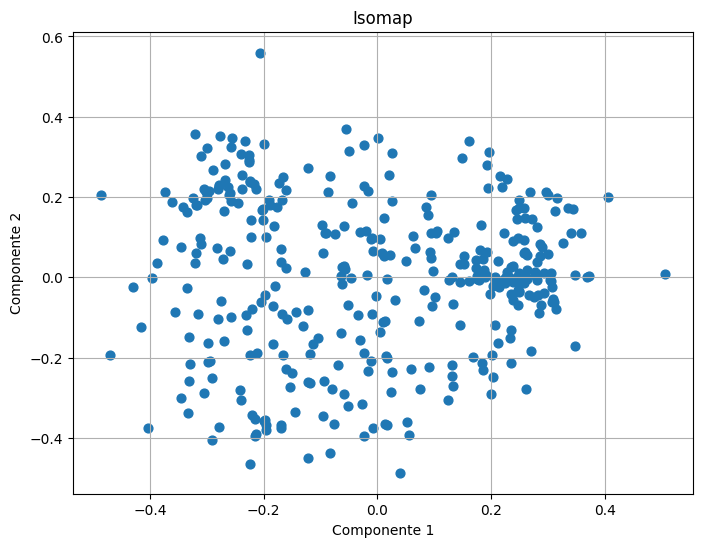

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import Isomap

# =========================
# carregar matriz
# =========================

D = np.load("matrizes/apo/1OMP_matriz.npy")

# =========================
# corrigir negativos
# =========================

if D.min() < 0:
    D = D - D.min()

# diagonal zero
np.fill_diagonal(D, 0)

# garantir simetria
D = (D + D.T)/2

# =========================
# Isomap
# =========================

iso = Isomap(
    n_neighbors=10,
    n_components=2,
    metric='precomputed'
)

X_iso = iso.fit_transform(D)

# =========================
# plot
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    X_iso[:,0],
    X_iso[:,1],
    s=40
)

plt.title("Isomap")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.grid(True)

plt.show()

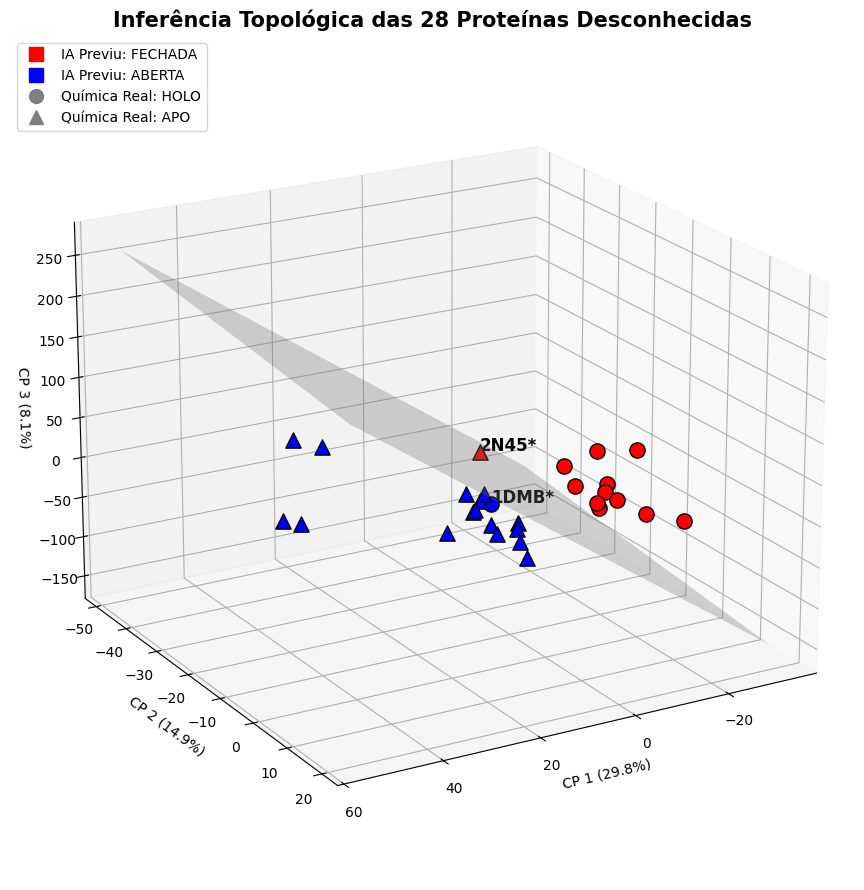

In [14]:
scaler_treinado = pipeline.named_steps['scaler']
pca_treinado = pipeline.named_steps['pca']
svm_treinado = pipeline.named_steps['svm']

# 2. Carregando as Paisagens das 28 proteínas (do Cache)
X_novas = []
ids_plot = []
tipos_plot = []
previsoes_plot = []

# Usamos as listas que o seu Bloco 6 já gerou
for pid, tipo, pred in zip(ids_novas_processadas, tipos_novas, previsoes_novas):
    cache_path = f"matrizes/cache/{pid}_paisagem_grau{GRAU_PRINCIPAL}.npy"
    if os.path.exists(cache_path):
        paisagem = np.load(cache_path)
        X_novas.append(paisagem)
        ids_plot.append(pid)
        tipos_plot.append(tipo.upper())
        previsoes_plot.append(pred)

X_novas = np.array(X_novas)

# 3. Projetando os dados cegos no espaço 3D do modelo
X_novas_scaled = scaler_treinado.transform(X_novas)
X_novas_pca = pca_treinado.transform(X_novas_scaled)

# 4. Matemática do Hiperplano (Fronteira de Decisão)
w = svm_treinado.coef_[0]
bias = svm_treinado.intercept_[0]

# Criando a "lona" do hiperplano com base nos limites das novas proteínas
xx, yy = np.meshgrid(
    np.linspace(X_novas_pca[:, 0].min() - 5, X_novas_pca[:, 0].max() + 5, 20),
    np.linspace(X_novas_pca[:, 1].min() - 5, X_novas_pca[:, 1].max() + 5, 20)
)
zz = (-w[0] * xx - w[1] * yy - bias) / w[2]

# =============================================================================
# 5. PLOTAGEM DO GRÁFICO
# =============================================================================
# Dica: Se quiser abrir fora do Jupyter, rode %matplotlib qt em uma célula antes
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Desenhando o Hiperplano separador
ax.plot_surface(xx, yy, zz, color='gray', alpha=0.3, rstride=100, cstride=100)

# Plotando as 28 proteínas
for i in range(len(ids_plot)):
    x_val, y_val, z_val = X_novas_pca[i]
    tipo = tipos_plot[i]  # 'HOLO' ou 'APO'
    pred = previsoes_plot[i] # 1 ou 0
    pid = ids_plot[i]
    
    # Cor = O que a Máquina previu (Vermelho=Fechada, Azul=Aberta)
    cor = 'red' if pred == 1 else 'blue'
    
    # Formato = O que a Química diz (Bolinha=Holo, Triângulo=Apo)
    marcador = 'o' if tipo == 'HOLO' else '^'
    
    ax.scatter(x_val, y_val, z_val, color=cor, marker=marcador, s=120, edgecolors='black', depthshade=True)
    
    # Destacando com texto as Anomalias Biológicas (O ápice do seu TCC)
    if pid in ['2N45', '1DMB']:
        # Coloca o nome da proteína flutuando um pouco acima do ponto
        ax.text(x_val, y_val, z_val + 1.5, f"{pid}*", color='black', fontsize=12, fontweight='bold')

# Criando legendas personalizadas para explicar cores e formas
import matplotlib.lines as mlines
legendas = [
    mlines.Line2D([], [], color='red', marker='s', linestyle='None', markersize=10, label='IA Previu: FECHADA'),
    mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=10, label='IA Previu: ABERTA'),
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=10, label='Química Real: HOLO'),
    mlines.Line2D([], [], color='gray', marker='^', linestyle='None', markersize=10, label='Química Real: APO')
]

ax.set_title("Inferência Topológica das 28 Proteínas Desconhecidas", fontsize=15, fontweight='bold')
ax.set_xlabel(f'CP 1 ({pca_treinado.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'CP 2 ({pca_treinado.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'CP 3 ({pca_treinado.explained_variance_ratio_[2]*100:.1f}%)')

ax.legend(handles=legendas, loc='upper left', bbox_to_anchor=(0.0, 1.0))

# Ajusta a câmera (rode no Jupyter para ver o melhor ângulo)
ax.view_init(elev=20, azim=60)

plt.tight_layout()
plt.savefig("inferencia_28_novas_tcc.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# %matplotlib tk
%matplotlib inline

In [15]:
import pandas as pd

distancias_brutas = pipeline.decision_function(X_novas)

dados_distancia = []

for pid, tipo, dist in zip(ids_plot, tipos_plot, distancias_brutas):
    # O valor absoluto é a distância física até a fronteira de decisão
    confianca = abs(dist)
    
    # Valores > 0 indicam a classe 1 (Fechada), valores < 0 indicam a classe 0 (Aberta)
    previsao = "FECHADA" if dist > 0 else "ABERTA"
    
    # Classificação analítica do estado conformacional
    if pid in ['2N45', '1DMB']:
        alerta = "⭐ ANOMALIA BIOLÓGICA"
    elif confianca < 0.5:
        alerta = "⚠️ FRONTEIRA (Estado Intermédio)"
    else:
        alerta = "✓ Conformação Rígida/Segura"
        
    dados_distancia.append({
        'PDB_ID': pid,
        'Química Real': tipo,
        'Previsão IA': previsao,
        'Distância Absoluta': round(confianca, 4),
        'Status': alerta
    })

# Cria um DataFrame e ordena para que as proteínas mais coladas ao plano apareçam no topo
df_distancias = pd.DataFrame(dados_distancia)
df_distancias = df_distancias.sort_values(by='Distância Absoluta')

print(df_distancias.to_string(index=False))

# Estatísticas de Prova
proteinas_comuns = df_distancias[~df_distancias['PDB_ID'].isin(['2N45', '1DMB'])]
media_comuns = proteinas_comuns['Distância Absoluta'].mean()

dist_2n45 = df_distancias[df_distancias['PDB_ID'] == '2N45']['Distância Absoluta'].values[0]
dist_1dmb = df_distancias[df_distancias['PDB_ID'] == '1DMB']['Distância Absoluta'].values[0]

print("\n" + "-" * 70)
print("RESUMO DA PROVA ESTATÍSTICA:")
print(f"➜ Distância Média das Proteínas Comuns: {media_comuns:.4f}")
print(f"➜ Distância da 2N45 (Apo Fechada):      {dist_2n45:.4f}")
print(f"➜ Distância da 1DMB (Holo Aberta):      {dist_1dmb:.4f}")
print("-" * 70)

PDB_ID Química Real Previsão IA  Distância Absoluta                      Status
  2N45          APO     FECHADA              0.1985        ⭐ ANOMALIA BIOLÓGICA
  2D21          APO      ABERTA              0.6017 ✓ Conformação Rígida/Segura
  8C8F          APO      ABERTA              0.7306 ✓ Conformação Rígida/Segura
  1DMB         HOLO      ABERTA              0.7676        ⭐ ANOMALIA BIOLÓGICA
  1MPB          APO      ABERTA              0.8794 ✓ Conformação Rígida/Segura
  1ZIU          APO      ABERTA              0.8820 ✓ Conformação Rígida/Segura
  2H25          APO      ABERTA              0.9732 ✓ Conformação Rígida/Segura
  5E24         HOLO     FECHADA              0.9863 ✓ Conformação Rígida/Segura
  3SER         HOLO     FECHADA              1.0395 ✓ Conformação Rígida/Segura
  3SET         HOLO     FECHADA              1.1151 ✓ Conformação Rígida/Segura
  3KJT          APO      ABERTA              1.1209 ✓ Conformação Rígida/Segura
  2MV0          APO      ABERTA         

In [18]:
import pandas as pd
import numpy as np
import gzip
import os
import warnings
from Bio.PDB import Superimposer
from Bio.PDB.MMCIFParser import MMCIFParser
warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURAÇÃO
# =============================================================================

REFERENCIA_FECHADA = '1ANF'
REFERENCIA_ABERTA  = '1OMP'

# =============================================================================
# FUNÇÕES AUXILIARES
# =============================================================================

def carregar_estrutura(pdb_id):
    """
    Carrega estrutura .cif.gz de dataset/apo/ ou dataset/holo/.
    Tenta holo primeiro, depois apo.
    """
    parser_cif = MMCIFParser(QUIET=True)

    for pasta in ['holo', 'apo']:
        caminho = f"dataset/{pasta}/{pdb_id.lower()}.cif.gz"
        if os.path.exists(caminho):
            with gzip.open(caminho, 'rt') as f:
                return parser_cif.get_structure(pdb_id, f)

    raise FileNotFoundError(
        f"Estrutura {pdb_id} não encontrada em dataset/apo/ nem dataset/holo/"
    )


def extrair_ca(estrutura, chain_id=None):
    """
    Extrai átomos Cα da estrutura.
    Se chain_id=None, pega a primeira chain disponível.
    Retorna lista de átomos Cα ordenados por resíduo.
    """
    model = estrutura[0]  # primeiro modelo (relevante para NMR)

    if chain_id is None:
        chain = list(model.get_chains())[0]
    else:
        chain = model[chain_id]

    ca_atoms = []
    for residuo in chain.get_residues():
        # Ignora heteroátomos (ligantes, água)
        if residuo.get_id()[0] != ' ':
            continue
        if 'CA' in residuo:
            ca_atoms.append(residuo['CA'])

    return ca_atoms


def calcular_rmsd(estrutura_ref, estrutura_alvo, chain_ref=None, chain_alvo=None):
    """
    Alinha estrutura_alvo sobre estrutura_ref via algoritmo de Kabsch
    e retorna o RMSD de Cα.
    Trunca automaticamente para o número de resíduos em comum.
    """
    ca_ref  = extrair_ca(estrutura_ref,  chain_ref)
    ca_alvo = extrair_ca(estrutura_alvo, chain_alvo)

    # Trunca para o menor tamanho (lida com 369 vs 370)
    n = min(len(ca_ref), len(ca_alvo))
    ca_ref  = ca_ref[:n]
    ca_alvo = ca_alvo[:n]

    sup = Superimposer()
    sup.set_atoms(ca_ref, ca_alvo)  # Kabsch internamente
    sup.apply(estrutura_alvo.get_atoms())

    return round(sup.rms, 4), n

# =============================================================================
# CARREGA CSV E REFERÊNCIAS
# =============================================================================

df = pd.read_csv("resultados_classificacao.csv")
print(f"Proteínas no CSV: {len(df)}")
print(df.to_string(index=False))

print("\nCarregando estruturas de referência...")
try:
    ref_fechada = carregar_estrutura(REFERENCIA_FECHADA)
    ref_aberta  = carregar_estrutura(REFERENCIA_ABERTA)
    print(f"  ✓ {REFERENCIA_FECHADA} (referência FECHADA) pronta.")
    print(f"  ✓ {REFERENCIA_ABERTA}  (referência ABERTA)  pronta.")
except FileNotFoundError as e:
    raise SystemExit(f"ERRO ao carregar referências: {e}")

# =============================================================================
# CÁLCULO DO RMSD PARA TODAS AS PROTEÍNAS DO CSV
# =============================================================================

print("\nCalculando RMSD...\n")

rmsd_fechada_col = []
rmsd_aberta_col  = []
n_residuos_col   = []
conclusao_col    = []

for _, row in df.iterrows():
    pdb_id            = row['PDB_ID']
    classificacao_svm = row['Classificacao']

    try:
        estrutura = carregar_estrutura(pdb_id)

        rmsd_vs_fechada, n_f = calcular_rmsd(ref_fechada, estrutura)
        rmsd_vs_aberta,  n_a = calcular_rmsd(ref_aberta,  estrutura)

        # Conclusão estrutural baseada no RMSD
        # (independente do SVM — é a validação ortogonal)
        conclusao_rmsd = "FECHADA" if rmsd_vs_fechada < rmsd_vs_aberta else "ABERTA"

        rmsd_fechada_col.append(rmsd_vs_fechada)
        rmsd_aberta_col.append(rmsd_vs_aberta)
        n_residuos_col.append(min(n_f, n_a))
        conclusao_col.append(conclusao_rmsd)

        concordancia = "✓" if conclusao_rmsd == classificacao_svm else "⚠ DIVERGE"
        print(f"  {pdb_id}: RMSD vs fechada={rmsd_vs_fechada:.4f} | "
              f"RMSD vs aberta={rmsd_vs_aberta:.4f} | "
              f"RMSD→{conclusao_rmsd} | SVM→{classificacao_svm} {concordancia}")

    except FileNotFoundError:
        print(f"  ⚠️  {pdb_id}: arquivo não encontrado. Pulando.")
        rmsd_fechada_col.append(None)
        rmsd_aberta_col.append(None)
        n_residuos_col.append(None)
        conclusao_col.append(None)

    except Exception as e:
        print(f"  ✗ {pdb_id}: erro — {e}. Pulando.")
        rmsd_fechada_col.append(None)
        rmsd_aberta_col.append(None)
        n_residuos_col.append(None)
        conclusao_col.append(None)

# =============================================================================
# SALVA CSV ENRIQUECIDO
# =============================================================================

df['RMSD_vs_Fechada'] = rmsd_fechada_col
df['RMSD_vs_Aberta']  = rmsd_aberta_col
df['N_Residuos']      = n_residuos_col
df['Conclusao_RMSD']  = conclusao_col
df['Concordancia']    = df.apply(
    lambda r: 'CONCORDA' if r['Classificacao'] == r['Conclusao_RMSD'] else 'DIVERGE'
    if r['Conclusao_RMSD'] is not None else 'SEM_DADOS',
    axis=1
)

df.to_csv("resultados_completos.csv", index=False)
print("\n✓ Resultados completos salvos em resultados_completos.csv")
print(df.to_string(index=False))

# =============================================================================
# RESUMO FINAL
# =============================================================================

df_validos  = df[df['Conclusao_RMSD'].notna()]
n_concorda  = (df_validos['Concordancia'] == 'CONCORDA').sum()
n_diverge   = (df_validos['Concordancia'] == 'DIVERGE').sum()
n_sem_dados = (df['Concordancia'] == 'SEM_DADOS').sum()

print(f"\n{'='*50}")
print(f"RESUMO DE CONCORDÂNCIA SVM × RMSD")
print(f"{'='*50}")
print(f"Concordam  : {n_concorda}/{len(df_validos)}")
print(f"Divergem   : {n_diverge}/{len(df_validos)}")
if n_sem_dados > 0:
    print(f"Sem dados  : {n_sem_dados} (arquivo não encontrado)")

if n_diverge > 0:
    print("\nProteínas com divergência (candidatas a estado intermediário):")
    for _, row in df_validos[df_validos['Concordancia'] == 'DIVERGE'].iterrows():
        print(f"  {row['PDB_ID']} | Conformacao={row['Conformacao']} | "
              f"SVM={row['Classificacao']} | RMSD={row['Conclusao_RMSD']} | "
              f"RMSD_F={row['RMSD_vs_Fechada']:.4f} | RMSD_A={row['RMSD_vs_Aberta']:.4f}")

Proteínas no CSV: 29
PDB_ID Conformacao Classificacao
  1DMB        HOLO        ABERTA
  3PUZ        HOLO       FECHADA
  3PV0        HOLO       FECHADA
  3SER        HOLO       FECHADA
  3SES        HOLO       FECHADA
  3SET        HOLO       FECHADA
  3SEV        HOLO       FECHADA
  3SEW        HOLO       FECHADA
  3SEX        HOLO       FECHADA
  4KHZ        HOLO       FECHADA
  5E24        HOLO       FECHADA
  8YBE        HOLO       FECHADA
  1EZO         APO        ABERTA
  1EZP         APO        ABERTA
  1MPB         APO        ABERTA
  1MPC         APO        ABERTA
  1ZIU         APO        ABERTA
  1ZJL         APO        ABERTA
  1ZKB         APO        ABERTA
  1ZMG         APO        ABERTA
  2D21         APO        ABERTA
  2H25         APO        ABERTA
  2KLF         APO        ABERTA
  2MV0         APO        ABERTA
  2N44         APO        ABERTA
  2N45         APO       FECHADA
  3KJT         APO        ABERTA
  7Z7H         APO        ABERTA
  8C8F         APO    